In [1]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q medmnist
!pip install -q shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# Imports
# ============================================================

import os

import cv2

import shap

import random

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import medmnist

from medmnist import BloodMNIST

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix

)

from skimage import morphology

from skimage.measure import (

    label,

    regionprops

)

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (

    Dense,

    Dropout,

    Input

)

from tensorflow.keras.optimizers import Adam

import tensorflow as tf

In [3]:
# ============================================================
# Global Constants
# ============================================================

DATA_FLAG = "bloodmnist"

IMAGE_SIZE = 28

RANDOM_SEED = 42

TEST_SIZE = 0.20

VALIDATION_SIZE = 0.10

MC_SAMPLES = 30

BACKGROUND_SIZE = 100

SHAP_RANDOM_SEED = 42

CLASS_NAMES = [

    "Basophil",

    "Eosinophil",

    "Erythroblast",

    "Immature Granulocyte",

    "Lymphocyte",

    "Monocyte",

    "Neutrophil",

    "Platelet"

]

# ============================================================
# Clinical Concept Names
# ============================================================

CONCEPT_NAMES = [

    # --------------------------------------------------------
    # Dominant Dark Region Morphology
    # --------------------------------------------------------

    "dark_region_area",

    "dark_region_solidity",

    "dark_region_eccentricity",

    "mean_dark_region_intensity",

    # --------------------------------------------------------
    # Global Image Appearance
    # --------------------------------------------------------

    "mean_image_brightness",

    "image_brightness_std"

]

# ============================================================
# Reproducibility
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

In [4]:
# ============================================================
# Project Directory Structure
# ============================================================

PROJECT_DIR = "ConceptScope"

# ------------------------------------------------------------
# Main Directories
# ------------------------------------------------------------

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "figures"
)

RESULT_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

CSV_DIR = os.path.join(
    PROJECT_DIR,
    "csv"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

# ------------------------------------------------------------
# Figure Directories
# ------------------------------------------------------------

CONCEPT_FIGURE_DIR = os.path.join(
    FIGURE_DIR,
    "concept_pipeline"
)

PREDICTION_FIGURE_DIR = os.path.join(
    FIGURE_DIR,
    "prediction"
)

UNCERTAINTY_FIGURE_DIR = os.path.join(
    FIGURE_DIR,
    "uncertainty"
)

PREDICTION_SHAP_FIGURE_DIR = os.path.join(
    FIGURE_DIR,
    "prediction_shap"
)

UNCERTAINTY_SHAP_FIGURE_DIR = os.path.join(
    FIGURE_DIR,
    "uncertainty_shap"
)

# ------------------------------------------------------------
# Results Directories
# ------------------------------------------------------------

CONCEPT_RESULTS_DIR = os.path.join(
    RESULT_DIR,
    "concept_pipeline"
)

PREDICTION_RESULTS_DIR = os.path.join(
    RESULT_DIR,
    "prediction"
)

UNCERTAINTY_RESULTS_DIR = os.path.join(
    RESULT_DIR,
    "uncertainty"
)

PREDICTION_SHAP_RESULTS_DIR = os.path.join(
    RESULT_DIR,
    "prediction_shap"
)


UNCERTAINTY_SHAP_RESULTS_DIR = os.path.join(
    RESULT_DIR,
    "uncertainty_shap"
)

# ------------------------------------------------------------
# CSV Directories
# ------------------------------------------------------------

CONCEPT_CSV_DIR = os.path.join(
    CSV_DIR,
    "concept_pipeline"
)


PREDICTION_CSV_DIR = os.path.join(
    CSV_DIR,
    "prediction"
)


UNCERTAINTY_CSV_DIR = os.path.join(
    CSV_DIR,
    "uncertainty"
)

PREDICTION_SHAP_CSV_DIR = os.path.join(
    CSV_DIR,
    "prediction_shap"
)

UNCERTAINTY_SHAP_CSV_DIR = os.path.join(
    CSV_DIR,
    "uncertainty_shap"
)

# ------------------------------------------------------------
# Model Directories
# ------------------------------------------------------------

CONCEPT_MODEL_DIR = os.path.join(
    MODEL_DIR,
    "concept_pipeline"
)


PREDICTION_MODEL_DIR = os.path.join(
    MODEL_DIR,
    "prediction"
)

UNCERTAINTY_MODEL_DIR = os.path.join(
    MODEL_DIR,
    "uncertainty"
)

PREDICTION_SHAP_MODEL_DIR = os.path.join(
    MODEL_DIR,
    "prediction_shap"
)

UNCERTAINTY_SHAP_MODEL_DIR = os.path.join(
    MODEL_DIR,
    "uncertainty_shap"
)

# ------------------------------------------------------------
# Create Directories
# ------------------------------------------------------------

DIRECTORIES = [

    PROJECT_DIR,

    FIGURE_DIR,
    RESULT_DIR,
    CSV_DIR,
    MODEL_DIR,

    # --------------------------------------------------------
    # Figure Directories
    # --------------------------------------------------------

    CONCEPT_FIGURE_DIR,
    PREDICTION_FIGURE_DIR,
    UNCERTAINTY_FIGURE_DIR,
    PREDICTION_SHAP_FIGURE_DIR,
    UNCERTAINTY_SHAP_FIGURE_DIR,

    # --------------------------------------------------------
    # Results Directories
    # --------------------------------------------------------

    CONCEPT_RESULTS_DIR,
    PREDICTION_RESULTS_DIR,
    UNCERTAINTY_RESULTS_DIR,
    PREDICTION_SHAP_RESULTS_DIR,
    UNCERTAINTY_SHAP_RESULTS_DIR,

    # --------------------------------------------------------
    # CSV Directories
    # --------------------------------------------------------

    CONCEPT_CSV_DIR,
    PREDICTION_CSV_DIR,
    UNCERTAINTY_CSV_DIR,
    PREDICTION_SHAP_CSV_DIR,
    UNCERTAINTY_SHAP_CSV_DIR,

    # --------------------------------------------------------
    # Model Directories
    # --------------------------------------------------------

    CONCEPT_MODEL_DIR,
    PREDICTION_MODEL_DIR,
    UNCERTAINTY_MODEL_DIR,
    PREDICTION_SHAP_MODEL_DIR,
    UNCERTAINTY_SHAP_MODEL_DIR

]

for directory in DIRECTORIES:

    os.makedirs(

        directory,

        exist_ok=True

    )

print("=" * 60)
print("Project Directory Structure Created")
print("=" * 60)

for directory in DIRECTORIES:

    print(directory)

Project Directory Structure Created
ConceptScope
ConceptScope/figures
ConceptScope/results
ConceptScope/csv
ConceptScope/models
ConceptScope/figures/concept_pipeline
ConceptScope/figures/prediction
ConceptScope/figures/uncertainty
ConceptScope/figures/prediction_shap
ConceptScope/figures/uncertainty_shap
ConceptScope/results/concept_pipeline
ConceptScope/results/prediction
ConceptScope/results/uncertainty
ConceptScope/results/prediction_shap
ConceptScope/results/uncertainty_shap
ConceptScope/csv/concept_pipeline
ConceptScope/csv/prediction
ConceptScope/csv/uncertainty
ConceptScope/csv/prediction_shap
ConceptScope/csv/uncertainty_shap
ConceptScope/models/concept_pipeline
ConceptScope/models/prediction
ConceptScope/models/uncertainty
ConceptScope/models/prediction_shap
ConceptScope/models/uncertainty_shap


In [5]:
# ============================================================
# Save Figure Helper Function
# ============================================================

def save_figure(

    filename,

    directory,

    dpi=300,

    bbox_inches="tight"

):
    """
    Saves the current matplotlib figure.

    Parameters
    ----------
    filename : str
        Figure filename without extension.

    directory : str
        Output directory.

    dpi : int
        Figure resolution.
    """

    filepath = os.path.join(

        directory,

        f"{filename}.png"

    )

    plt.savefig(

        filepath,

        dpi=dpi,

        bbox_inches=bbox_inches

    )

In [6]:
# ============================================================
# Save CSV Helper Function
# ============================================================

def save_csv(

    dataframe,

    filename,

    directory,

    index=False

):
    """
    Saves a pandas DataFrame as CSV.

    Parameters
    ----------
    dataframe : pd.DataFrame

    filename : str

    directory : str
    """

    filepath = os.path.join(

        directory,

        f"{filename}.csv"

    )

    dataframe.to_csv(

        filepath,

        index=index

    )

In [7]:
# ============================================================
# Download BloodMNIST Dataset
# ============================================================

dataset_train = BloodMNIST(

    split="train",

    download=True

)

dataset_validation = BloodMNIST(

    split="val",

    download=True

)

dataset_test = BloodMNIST(

    split="test",

    download=True

)

print("=" * 60)
print("BloodMNIST Downloaded Successfully")
print("=" * 60)

print(f"Training Samples   : {len(dataset_train)}")
print(f"Validation Samples : {len(dataset_validation)}")
print(f"Test Samples       : {len(dataset_test)}")

100%|██████████| 35.5M/35.5M [00:08<00:00, 4.23MB/s]


BloodMNIST Downloaded Successfully
Training Samples   : 11959
Validation Samples : 1712
Test Samples       : 3421


In [8]:
# ============================================================
# Extract Raw Images and Labels
# ============================================================

# ------------------------------------------------------------
# Training Set
# ------------------------------------------------------------

raw_train_images = dataset_train.imgs

raw_train_labels = dataset_train.labels.squeeze()

# ------------------------------------------------------------
# Validation Set
# ------------------------------------------------------------

raw_validation_images = dataset_validation.imgs

raw_validation_labels = dataset_validation.labels.squeeze()

# ------------------------------------------------------------
# Test Set
# ------------------------------------------------------------

raw_test_images = dataset_test.imgs

raw_test_labels = dataset_test.labels.squeeze()

print("=" * 60)
print("Raw Dataset Summary")
print("=" * 60)

print()

print("Training Set")

print("Images :", raw_train_images.shape)

print("Labels :", raw_train_labels.shape)

print()

print("Validation Set")

print("Images :", raw_validation_images.shape)

print("Labels :", raw_validation_labels.shape)

print()

print("Test Set")

print("Images :", raw_test_images.shape)

print("Labels :", raw_test_labels.shape)

Raw Dataset Summary

Training Set
Images : (11959, 28, 28, 3)
Labels : (11959,)

Validation Set
Images : (1712, 28, 28, 3)
Labels : (1712,)

Test Set
Images : (3421, 28, 28, 3)
Labels : (3421,)


In [9]:
# ============================================================
# Dataset Quality Assessment
# ============================================================

print("=" * 60)
print("Dataset Quality Assessment")
print("=" * 60)

# ------------------------------------------------------------
# Image Information
# ------------------------------------------------------------

print(f"Training Image Shape      : {raw_train_images.shape}")
print(f"Validation Image Shape    : {raw_validation_images.shape}")
print(f"Test Image Shape          : {raw_test_images.shape}")

print()

print(f"Image Data Type           : {raw_train_images.dtype}")

print(f"Pixel Value Range         : {raw_train_images.min()} - {raw_train_images.max()}")

print()

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

print(f"Missing Pixels (Train)    : {np.isnan(raw_train_images).sum()}")
print(f"Missing Labels (Train)    : {np.isnan(raw_train_labels).sum()}")

print()

# ------------------------------------------------------------
# Duplicate Images
# ------------------------------------------------------------

train_images_flat = raw_train_images.reshape(

    raw_train_images.shape[0],

    -1

)

duplicate_images = (

    train_images_flat.shape[0]

    -

    np.unique(

        train_images_flat,

        axis=0

    ).shape[0]

)

print(f"Duplicate Images          : {duplicate_images}")

print()

# ------------------------------------------------------------
# Class Distribution
# ------------------------------------------------------------

class_distribution = pd.DataFrame({

    "Class" : CLASS_NAMES,

    "Count" : np.bincount(

        raw_train_labels,

        minlength=len(CLASS_NAMES)

    )

})

print("Training Class Distribution")

display(class_distribution)

Dataset Quality Assessment
Training Image Shape      : (11959, 28, 28, 3)
Validation Image Shape    : (1712, 28, 28, 3)
Test Image Shape          : (3421, 28, 28, 3)

Image Data Type           : uint8
Pixel Value Range         : 0 - 255

Missing Pixels (Train)    : 0
Missing Labels (Train)    : 0

Duplicate Images          : 8

Training Class Distribution


,Class,Count
0,Basophil,852
1,Eosinophil,2181
2,Erythroblast,1085
3,Immature Granulocyte,2026
4,Lymphocyte,849
5,Monocyte,993
6,Neutrophil,2330
7,Platelet,1643


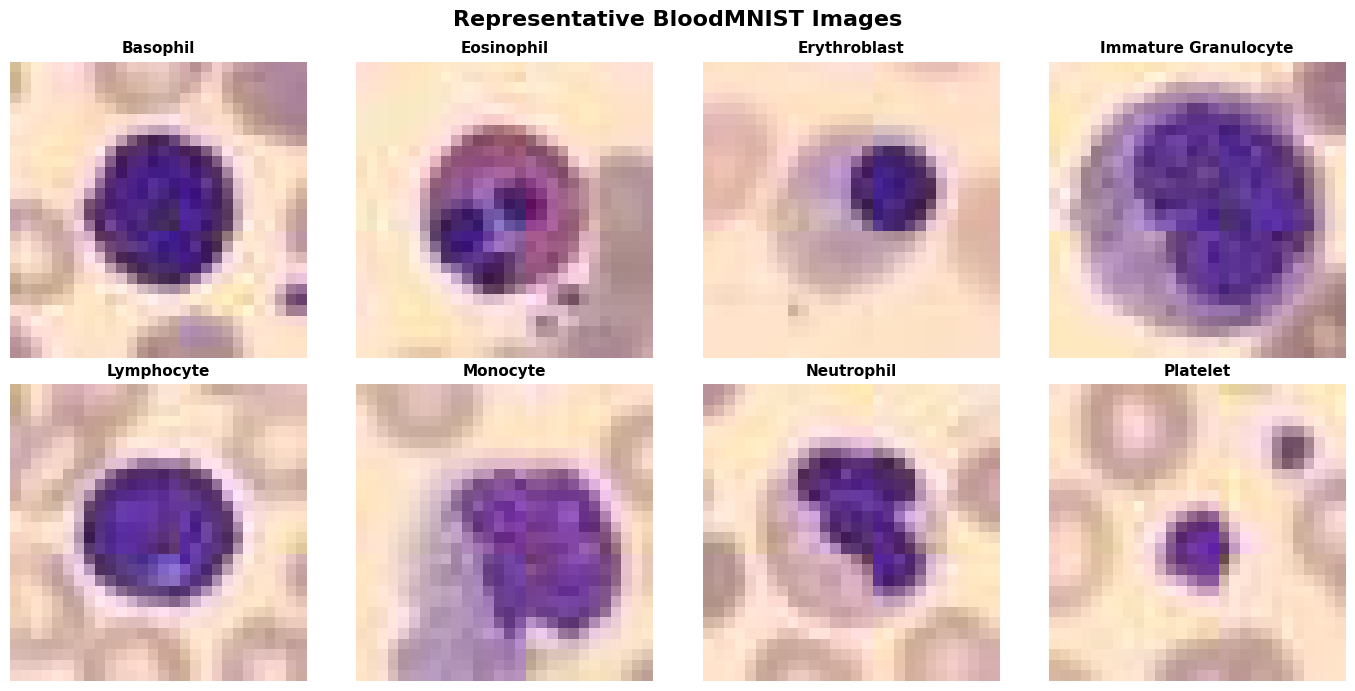

In [10]:
# ============================================================
# Representative Images from Each Blood Cell Class
# ============================================================

plt.figure(figsize=(14, 7))

for class_index, class_name in enumerate(CLASS_NAMES):

    # --------------------------------------------------------
    # Find First Image Belonging to Current Class
    # --------------------------------------------------------

    sample_index = np.where(

        raw_train_labels == class_index

    )[0][0]

    # --------------------------------------------------------
    # Display Image
    # --------------------------------------------------------

    plt.subplot(

        2,

        4,

        class_index + 1

    )

    plt.imshow(

        raw_train_images[sample_index]

    )

    plt.title(

        class_name,

        fontsize=11,

        fontweight="bold"

    )

    plt.axis("off")

plt.suptitle(

    "Representative BloodMNIST Images",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

In [11]:
# ============================================================
# Global Image Statistics Exploration
# ============================================================

global_image_statistics = []

for image in raw_train_images:

    # --------------------------------------------------------
    # Grayscale Image
    # --------------------------------------------------------

    grayscale_image = cv2.cvtColor(

        image,

        cv2.COLOR_RGB2GRAY

    )

    # --------------------------------------------------------
    # HSV Image
    # --------------------------------------------------------

    hsv_image = cv2.cvtColor(

        image,

        cv2.COLOR_RGB2HSV

    )

    # --------------------------------------------------------
    # RGB Channels
    # --------------------------------------------------------

    red_channel = image[:, :, 0]

    green_channel = image[:, :, 1]

    blue_channel = image[:, :, 2]

    # --------------------------------------------------------
    # Candidate Statistics
    # --------------------------------------------------------

    global_image_statistics.append({

        "mean_brightness":

            np.mean(grayscale_image),

        "std_brightness":

            np.std(grayscale_image),

        "contrast":

            np.max(grayscale_image) -
            np.min(grayscale_image),

        "mean_saturation":

            np.mean(hsv_image[:, :, 1]),

        "std_saturation":

            np.std(hsv_image[:, :, 1]),

        "mean_red":

            np.mean(red_channel),

        "mean_green":

            np.mean(green_channel),

        "mean_blue":

            np.mean(blue_channel)

    })

global_image_statistics = pd.DataFrame(

    global_image_statistics

)

global_image_statistics["Class"] = raw_train_labels

print("=" * 70)
print("Global Image Statistics")
print("=" * 70)

display(

    global_image_statistics.head()

)

Global Image Statistics


,mean_brightness,std_brightness,contrast,mean_saturation,std_saturation,mean_red,mean_green,mean_blue,Class
0,206.640306,35.025730,185,55.497449,20.534006,229.761480,198.801020,186.278061,7
1,153.077806,61.512072,198,83.400510,49.513916,172.903061,139.987245,168.696429,3
2,190.158163,52.712790,197,63.846939,36.749976,212.646684,180.686224,179.982143,6
3,174.524235,56.351434,208,70.733418,41.555091,197.942602,162.549745,174.568878,6
4,199.456633,37.315781,161,54.794643,20.632781,222.304847,190.656888,184.834184,7


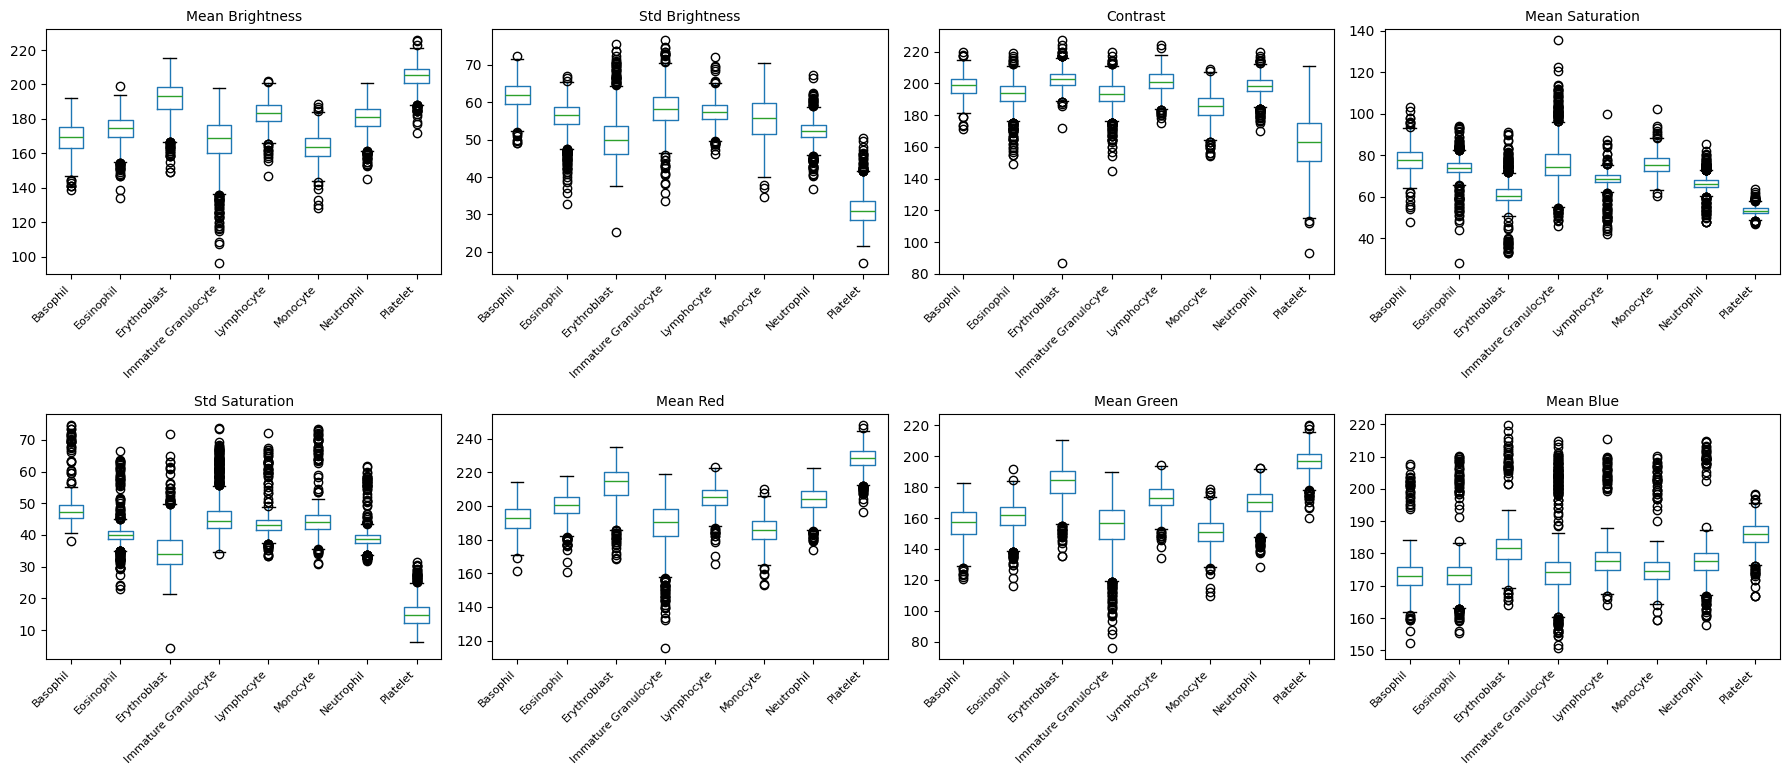

In [12]:
# ============================================================
# Global Statistics Across Classes
# ============================================================

statistics = [

    "mean_brightness",

    "std_brightness",

    "contrast",

    "mean_saturation",

    "std_saturation",

    "mean_red",

    "mean_green",

    "mean_blue"

]

fig, axes = plt.subplots(

    2,

    4,

    figsize=(18, 8)

)

axes = axes.flatten()

for i, statistic in enumerate(statistics):

    global_image_statistics.boxplot(

        column=statistic,

        by="Class",

        ax=axes[i],

        grid=False

    )

    axes[i].set_title(

        statistic.replace("_", " ").title(),

        fontsize=10

    )

    axes[i].set_xlabel("")

    axes[i].set_ylabel("")

    axes[i].set_xticklabels(

        CLASS_NAMES,

        rotation=45,

        ha="right",

        fontsize=8

    )

plt.suptitle("")

plt.tight_layout()

plt.show()

In [13]:
# ============================================================
# Clinical Concept Design
# ============================================================

clinical_concept_summary = pd.DataFrame({

    "Concept": [

        "Dark Region Area",

        "Dark Region Solidity",

        "Dark Region Eccentricity",

        "Mean Dark Region Intensity",

        "Mean Image Brightness",

        "Image Brightness Standard Deviation"

    ],

    "Concept Family": [

        "Dominant Dark Region Morphology",

        "Dominant Dark Region Morphology",

        "Dominant Dark Region Morphology",

        "Dominant Dark Region Morphology",

        "Global Image Appearance",

        "Global Image Appearance"

    ],

    "Clinical Interpretation": [

        "Size of the dominant stained intracellular structure",

        "Compactness of the dominant stained intracellular structure",

        "Shape and lobulation of the dominant stained intracellular structure",

        "Average staining intensity of the dominant stained intracellular structure",

        "Overall image staining brightness",

        "Variation in image brightness representing staining heterogeneity"

    ]

})

print("=" * 70)
print("Clinical Concept Design")
print("=" * 70)

display(clinical_concept_summary)

print()

print(
    "Note: The dominant dark intracellular region primarily "
    "corresponds to the nucleus in nucleated blood cells and "
    "to the granulomere in platelets. Consequently, concepts "
    "derived from this region should be interpreted as "
    "image-derived morphological descriptors rather than "
    "anatomically verified nuclear measurements."
)

Clinical Concept Design


,Concept,Concept Family,Clinical Interpretation
0,Dark Region Area,Dominant Dark Region Morphology,Size of the dominant stained intracellular str...
1,Dark Region Solidity,Dominant Dark Region Morphology,Compactness of the dominant stained intracellu...
2,Dark Region Eccentricity,Dominant Dark Region Morphology,Shape and lobulation of the dominant stained i...
3,Mean Dark Region Intensity,Dominant Dark Region Morphology,Average staining intensity of the dominant sta...
4,Mean Image Brightness,Global Image Appearance,Overall image staining brightness
5,Image Brightness Standard Deviation,Global Image Appearance,Variation in image brightness representing sta...



Note: The dominant dark intracellular region primarily corresponds to the nucleus in nucleated blood cells and to the granulomere in platelets. Consequently, concepts derived from this region should be interpreted as image-derived morphological descriptors rather than anatomically verified nuclear measurements.


In [14]:
# ============================================================
# Dark Region Segmentation
# ============================================================

def segment_dark_region(
    image
):
    """
    Segments the dominant dark intracellular region.

    For nucleated blood cells, this primarily corresponds
    to the nucleus.

    For platelets, this primarily corresponds to the
    granulomere.

    Parameters
    ----------
    image : ndarray
        RGB BloodMNIST image.

    Returns
    -------
    dark_region_mask : ndarray
        Binary mask of the dominant dark region.

    best_region : RegionProperties
        Selected connected component.
    """

    # --------------------------------------------------------
    # RGB -> Grayscale
    # --------------------------------------------------------

    grayscale_image = cv2.cvtColor(

        image,

        cv2.COLOR_RGB2GRAY

    )

    # --------------------------------------------------------
    # Gaussian Blur
    # --------------------------------------------------------

    blurred_image = cv2.GaussianBlur(

        grayscale_image,

        (3, 3),

        0

    )

    # --------------------------------------------------------
    # Otsu Threshold
    # --------------------------------------------------------

    _, dark_region_mask = cv2.threshold(

        blurred_image,

        0,

        255,

        cv2.THRESH_BINARY_INV +

        cv2.THRESH_OTSU

    )

    # --------------------------------------------------------
    # Morphological Cleanup
    # --------------------------------------------------------

    dark_region_mask = morphology.remove_small_objects(

        dark_region_mask.astype(bool),

        min_size=8

    )

    dark_region_mask = morphology.remove_small_holes(

        dark_region_mask,

        area_threshold=10

    )

    dark_region_mask = dark_region_mask.astype(np.uint8)

    # --------------------------------------------------------
    # Connected Components
    # --------------------------------------------------------

    labels = label(

        dark_region_mask

    )

    regions = regionprops(

        labels

    )

    center_y = image.shape[0] / 2

    center_x = image.shape[1] / 2

    best_region = None

    best_score = -np.inf

    # --------------------------------------------------------
    # Select Dominant Central Region
    # --------------------------------------------------------

    for region in regions:

        cy, cx = region.centroid

        distance = np.sqrt(

            (cx - center_x) ** 2 +

            (cy - center_y) ** 2

        )

        score = (

            region.area

            -

            2 * distance

        )

        if score > best_score:

            best_score = score

            best_region = region

    # --------------------------------------------------------
    # Final Mask
    # --------------------------------------------------------

    final_mask = np.zeros_like(

        dark_region_mask

    )

    if best_region is not None:

        final_mask[

            labels == best_region.label

        ] = 1

    return final_mask.astype(np.uint8), best_region

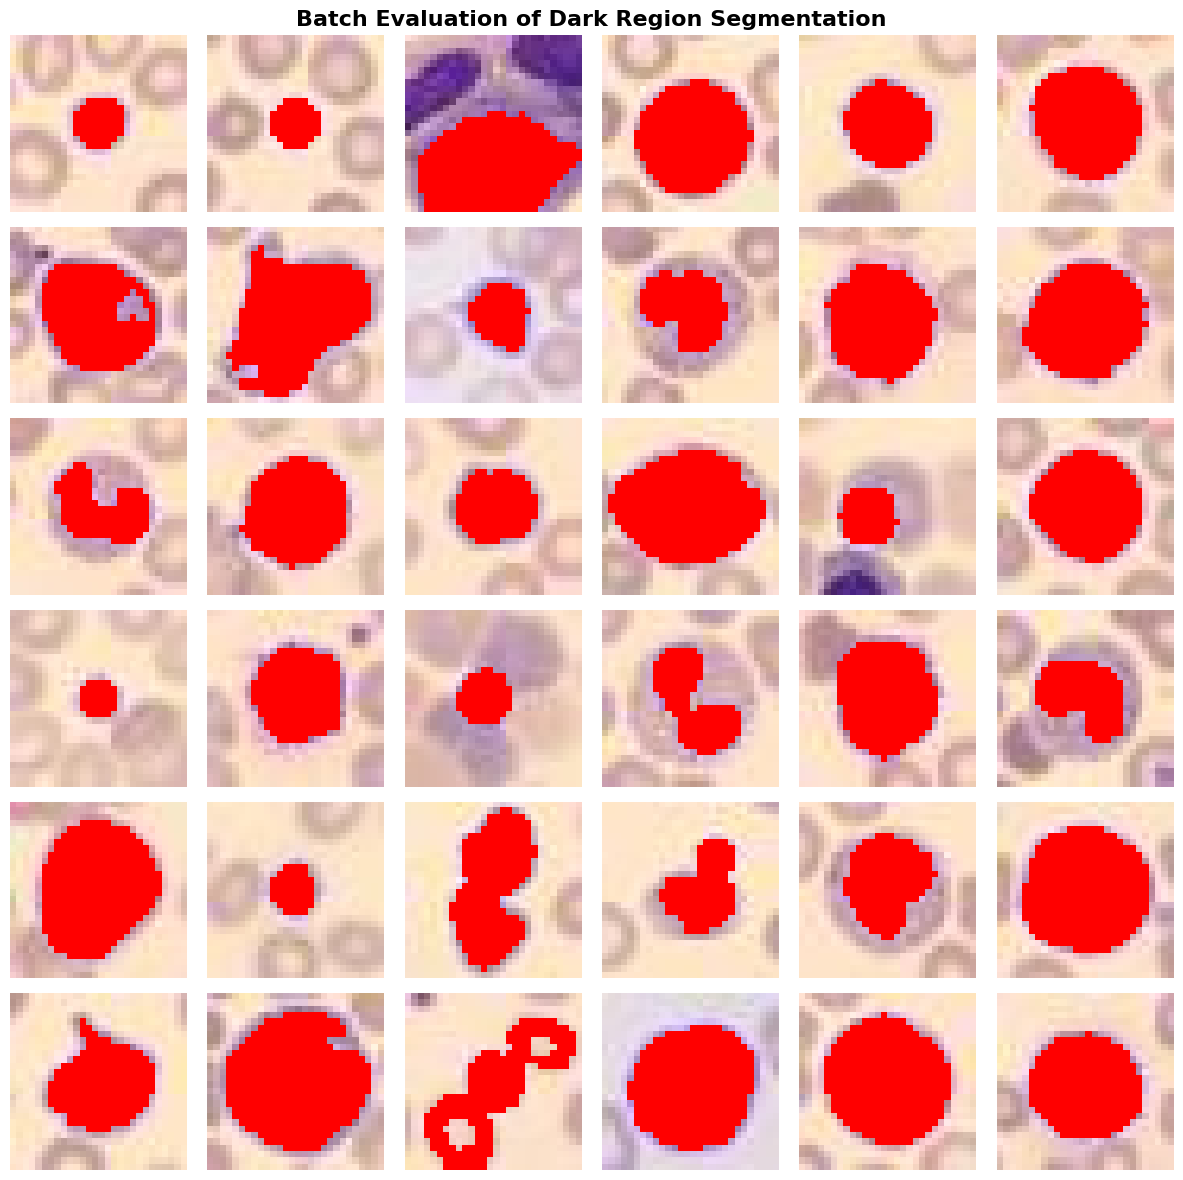

In [15]:
# ============================================================
# Batch Dark Region Segmentation Evaluation
# ============================================================

random.seed(RANDOM_STATE)

NUM_SAMPLES = 36

sample_indices = random.sample(

    range(len(raw_train_images)),

    NUM_SAMPLES

)

fig, axes = plt.subplots(

    6,

    6,

    figsize=(12, 12)

)

for ax, sample_idx in zip(

    axes.ravel(),

    sample_indices

):

    image = raw_train_images[

        sample_idx

    ]

    dark_region_mask, _ = segment_dark_region(

        image

    )

    # --------------------------------------------------------
    # Overlay
    # --------------------------------------------------------

    overlay = image.copy()

    overlay[

        dark_region_mask == 1

    ] = [

        255,

        0,

        0

    ]

    ax.imshow(

        overlay

    )

    ax.axis(

        "off"

    )

plt.suptitle(

    "Batch Evaluation of Dark Region Segmentation",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "batch_dark_region_segmentation",

    CONCEPT_FIGURE_DIR

)

plt.show()

In [16]:
# ============================================================
# Dark Region Feature Extraction
# ============================================================

def extract_dark_region_features(

    image,

    dark_region_mask,

    region

):
    """
    Extracts morphology and intensity features from the
    dominant dark intracellular region.

    Parameters
    ----------
    image : ndarray
        RGB BloodMNIST image.

    dark_region_mask : ndarray
        Binary mask returned by segment_dark_region().

    region : RegionProperties
        Selected connected component.

    Returns
    -------
    dict
        Dark region feature dictionary.
    """

    # --------------------------------------------------------
    # Convert to Grayscale
    # --------------------------------------------------------

    grayscale_image = cv2.cvtColor(

        image,

        cv2.COLOR_RGB2GRAY

    )

    # --------------------------------------------------------
    # Empty Region Check
    # --------------------------------------------------------

    if region is None:

        return {

            "dark_region_area": 0,

            "dark_region_solidity": 0,

            "dark_region_eccentricity": 0,

            "mean_dark_region_intensity": 0

        }

    # --------------------------------------------------------
    # Dark Region Pixels
    # --------------------------------------------------------

    dark_region_pixels = grayscale_image[

        dark_region_mask == 1

    ]

    # --------------------------------------------------------
    # Feature Dictionary
    # --------------------------------------------------------

    feature_dictionary = {

        "dark_region_area":

            float(region.area),

        "dark_region_solidity":

            float(region.solidity),

        "dark_region_eccentricity":

            float(region.eccentricity),

        "mean_dark_region_intensity":

            float(

                np.mean(

                    dark_region_pixels

                )

            )

    }

    return feature_dictionary

In [17]:
# ============================================================
# Global Image Feature Extraction
# ============================================================

def extract_global_image_features(

    image

):
    """
    Extracts global appearance features from the image.

    Parameters
    ----------
    image : ndarray
        RGB BloodMNIST image.

    Returns
    -------
    dict
        Global appearance feature dictionary.
    """

    grayscale_image = cv2.cvtColor(

        image,

        cv2.COLOR_RGB2GRAY

    )

    feature_dictionary = {

        "mean_image_brightness":

            float(

                np.mean(

                    grayscale_image

                )

            ),

        "image_brightness_std":

            float(

                np.std(

                    grayscale_image

                )

            )

    }

    return feature_dictionary

In [18]:
# ============================================================
# Concept Vector Extraction
# ============================================================

def extract_concept_vector(
    image
):
    """
    Extracts the complete concept vector for a BloodMNIST image.

    Parameters
    ----------
    image : ndarray
        RGB BloodMNIST image.

    Returns
    -------
    dict
        Dictionary containing all clinical concepts.
    """

    # --------------------------------------------------------
    # Dark Region Segmentation
    # --------------------------------------------------------

    dark_region_mask, region = segment_dark_region(
        image
    )

    # --------------------------------------------------------
    # Dark Region Features
    # --------------------------------------------------------

    dark_region_features = extract_dark_region_features(

        image,

        dark_region_mask,

        region

    )

    # --------------------------------------------------------
    # Global Image Features
    # --------------------------------------------------------

    global_image_features = extract_global_image_features(

        image

    )

    # --------------------------------------------------------
    # Merge Concept Dictionaries
    # --------------------------------------------------------

    concept_vector = {

        **dark_region_features,

        **global_image_features

    }

    return concept_vector

In [19]:
# ============================================================
# Concept Extraction Quality Control
# ============================================================

random.seed(RANDOM_STATE)

NUM_QC_SAMPLES = 20

qc_indices = random.sample(

    range(len(raw_train_images)),

    NUM_QC_SAMPLES

)

concept_dataframe = pd.DataFrame(

    [

        extract_concept_vector(

            raw_train_images[idx]

        )

        for idx in qc_indices

    ]

)

print("=" * 70)
print("Concept Extraction Quality Control")
print("=" * 70)

display(

    concept_dataframe

)

print()

print("Missing Values")

print(

    concept_dataframe.isnull().sum()

)

print()

print("Feature Ranges")

display(

    concept_dataframe.describe().T

)

print("=" * 70)
print("Concept Validation")
print("=" * 70)

assert (concept_dataframe["dark_region_area"] > 0).all()

assert (
    concept_dataframe["dark_region_solidity"]
    .between(0, 1)
).all()

assert (
    concept_dataframe["dark_region_eccentricity"]
    .between(0, 1)
).all()

assert (
    concept_dataframe["mean_dark_region_intensity"]
    .between(0, 255)
).all()

assert (
    concept_dataframe["mean_image_brightness"]
    .between(0, 255)
).all()

assert (
    concept_dataframe["image_brightness_std"] >= 0
).all()

print("✓ All concept validation checks passed.")

Concept Extraction Quality Control


,dark_region_area,dark_region_solidity,dark_region_eccentricity,mean_dark_region_intensity,mean_image_brightness,image_brightness_std
0,54.0,1.000000,0.368694,105.259259,206.110969,34.382552
1,52.0,1.000000,0.000000,131.500000,204.432398,33.123039
2,311.0,0.956923,0.781438,82.707395,108.616071,40.996756
3,253.0,0.951128,0.273280,105.229249,177.021684,56.521472
4,147.0,0.942308,0.392696,77.809524,194.229592,60.945156
5,242.0,0.952756,0.433159,106.590909,181.400510,55.905011
6,234.0,0.903475,0.585395,91.991453,163.765306,54.541933
7,341.0,0.867684,0.669918,106.483871,163.760204,56.721425
8,77.0,0.916667,0.549083,77.233766,196.727041,44.937252
9,129.0,0.895833,0.635378,86.209302,184.244898,52.776350



Missing Values
dark_region_area              0
dark_region_solidity          0
dark_region_eccentricity      0
mean_dark_region_intensity    0
mean_image_brightness         0
image_brightness_std          0
dtype: int64

Feature Ranges


,count,mean,std,min,25%,50%,75%,max
dark_region_area,20.0,183.000000,97.975292,32.000000,107.750000,197.500000,246.250000,341.000000
dark_region_solidity,20.0,0.940322,0.046768,0.802721,0.929167,0.949813,0.959752,1.000000
dark_region_eccentricity,20.0,0.440324,0.215842,0.000000,0.349968,0.411601,0.597890,0.795295
mean_dark_region_intensity,20.0,95.424511,14.239253,77.233766,84.322341,95.646716,105.236752,131.500000
mean_image_brightness,20.0,180.804337,21.763471,108.616071,171.907844,181.767219,195.055804,206.110969
image_brightness_std,20.0,50.939197,9.878591,28.231573,47.345021,54.520239,56.775084,62.837644


Concept Validation
✓ All concept validation checks passed.


In [20]:
# ============================================================
# Build Concept Dataset
# ============================================================

from tqdm.auto import tqdm

def build_concept_dataset(

    images,

    labels

):
    """
    Builds a concept dataset from a collection of images.

    Parameters
    ----------
    images : ndarray
        BloodMNIST images.

    labels : ndarray
        Corresponding class labels.

    Returns
    -------
    pd.DataFrame
        Concept dataset with labels.
    """

    concept_rows = []

    print("=" * 70)
    print("Extracting Concepts")
    print("=" * 70)

    for image, label in tqdm(

        zip(images, labels),

        total=len(images)

    ):

        concept_vector = extract_concept_vector(

            image

        )

        concept_vector["label"] = int(label)

        concept_rows.append(

            concept_vector

        )

    concept_dataframe = pd.DataFrame(

        concept_rows

    )

    return concept_dataframe

In [21]:
# ============================================================
# Build Concept Datasets
# ============================================================

concept_train_df = build_concept_dataset(

    raw_train_images,

    raw_train_labels

)

concept_validation_df = build_concept_dataset(

    raw_validation_images,

    raw_validation_labels

)

concept_test_df = build_concept_dataset(

    raw_test_images,

    raw_test_labels

)

print("=" * 70)
print("Concept Dataset Construction Complete")
print("=" * 70)

print()

print(
    "Training Set   :",
    concept_train_df.shape
)

print(
    "Validation Set :",
    concept_validation_df.shape
)

print(
    "Test Set       :",
    concept_test_df.shape
)

Extracting Concepts


  0%|          | 0/11959 [00:00<?, ?it/s]

Extracting Concepts


  0%|          | 0/1712 [00:00<?, ?it/s]

Extracting Concepts


  0%|          | 0/3421 [00:00<?, ?it/s]

Concept Dataset Construction Complete

Training Set   : (11959, 7)
Validation Set : (1712, 7)
Test Set       : (3421, 7)


In [22]:
# ============================================================
# Concept Dataset Quality Assessment
# ============================================================

print("=" * 70)
print("Concept Dataset Quality Assessment")
print("=" * 70)

print()

# ------------------------------------------------------------
# Dataset Shapes
# ------------------------------------------------------------

print("Training Set Shape   :", concept_train_df.shape)

print("Validation Set Shape :", concept_validation_df.shape)

print("Test Set Shape       :", concept_test_df.shape)

print()

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

print("Missing Values")

display(

    pd.DataFrame({

        "Training":

            concept_train_df.isnull().sum(),

        "Validation":

            concept_validation_df.isnull().sum(),

        "Test":

            concept_test_df.isnull().sum()

    })

)

# ------------------------------------------------------------
# Infinite Values
# ------------------------------------------------------------

print()

print("Infinite Values")

print(

    "Training   :",

    np.isinf(

        concept_train_df.select_dtypes(include=np.number)

    ).sum().sum()

)

print(

    "Validation :",

    np.isinf(

        concept_validation_df.select_dtypes(include=np.number)

    ).sum().sum()

)

print(

    "Test       :",

    np.isinf(

        concept_test_df.select_dtypes(include=np.number)

    ).sum().sum()

)

print()

# ------------------------------------------------------------
# Duplicate Samples
# ------------------------------------------------------------

print("Duplicate Rows")

print(

    "Training   :",

    concept_train_df.duplicated().sum()

)

print(

    "Validation :",

    concept_validation_df.duplicated().sum()

)

print(

    "Test       :",

    concept_test_df.duplicated().sum()

)

Concept Dataset Quality Assessment

Training Set Shape   : (11959, 7)
Validation Set Shape : (1712, 7)
Test Set Shape       : (3421, 7)

Missing Values


,Training,Validation,Test
dark_region_area,0,0,0
dark_region_solidity,0,0,0
dark_region_eccentricity,0,0,0
mean_dark_region_intensity,0,0,0
mean_image_brightness,0,0,0
image_brightness_std,0,0,0
label,0,0,0



Infinite Values
Training   : 0
Validation : 0
Test       : 0

Duplicate Rows
Training   : 8
Validation : 0
Test       : 0


In [23]:
# ============================================================
# Concept Dataset Overview
# ============================================================

print("=" * 70)
print("Training Concept Dataset Overview")
print("=" * 70)

print()

print("First Five Samples")

display(

    concept_train_df.head()

)

print()

print("Summary Statistics")

display(

    concept_train_df.describe()

)

print()

print("Training Class Distribution")

class_distribution = (

    concept_train_df["label"]

    .value_counts()

    .sort_index()

    .rename(index=dict(enumerate(CLASS_NAMES)))

)

display(

    class_distribution.to_frame(

        name="Count"

    )

)

Training Concept Dataset Overview

First Five Samples


,dark_region_area,dark_region_solidity,dark_region_eccentricity,mean_dark_region_intensity,mean_image_brightness,image_brightness_std,label
0,50.0,0.892857,0.402313,119.180000,206.640306,35.025730,7
1,359.0,0.952255,0.440122,97.467967,153.077806,61.512072,3
2,116.0,0.906250,0.793798,79.500000,190.158163,52.712790,6
3,181.0,0.819005,0.879328,88.513812,174.524235,56.351434,6
4,85.0,0.965909,0.219227,111.035294,199.456633,37.315781,7



Summary Statistics


,dark_region_area,dark_region_solidity,dark_region_eccentricity,mean_dark_region_intensity,mean_image_brightness,image_brightness_std,label
count,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000
mean,209.022326,0.914293,0.532977,100.966282,179.556191,52.353818,3.701898
std,88.674258,0.072357,0.204305,25.626081,15.440160,9.902173,2.307377
min,29.000000,0.455598,0.000000,54.375000,96.585459,17.087121,0.000000
25%,141.000000,0.890450,0.371677,85.353907,169.454082,50.055976,1.000000
50%,205.000000,0.944984,0.513343,94.909091,178.406888,54.567127,3.000000
75%,272.000000,0.960938,0.701720,107.174757,188.211735,58.641632,6.000000
max,722.000000,1.000000,0.974800,199.709091,225.556122,76.567039,7.000000



Training Class Distribution


,Count
label,
Basophil,852
Eosinophil,2181
Erythroblast,1085
Immature Granulocyte,2026
Lymphocyte,849
Monocyte,993
Neutrophil,2330
Platelet,1643


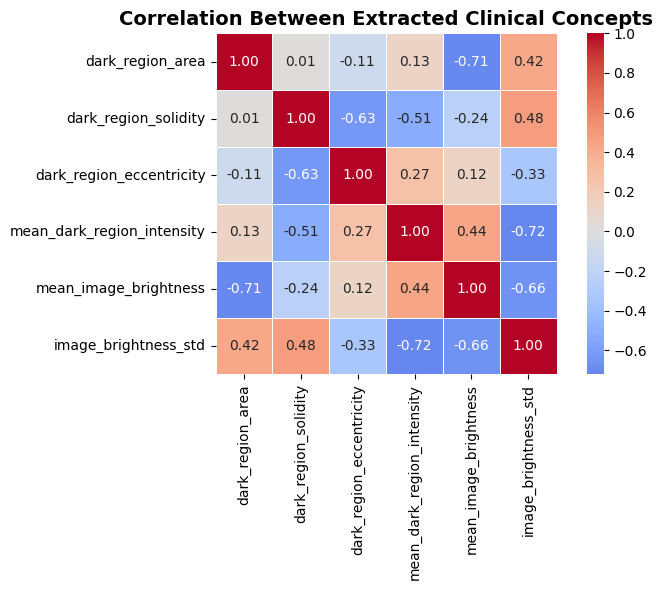

In [24]:
# ============================================================
# Correlation Heatmap
# ============================================================

import seaborn as sns

correlation_matrix = concept_train_df[

    CONCEPT_NAMES

].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(

    correlation_matrix,

    annot=True,

    cmap="coolwarm",

    center=0,

    square=True,

    linewidths=0.5,

    fmt=".2f"

)

plt.title(

    "Correlation Between Extracted Clinical Concepts",

    fontsize=14,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "concept_correlation_heatmap",

    CONCEPT_FIGURE_DIR

)

plt.show()

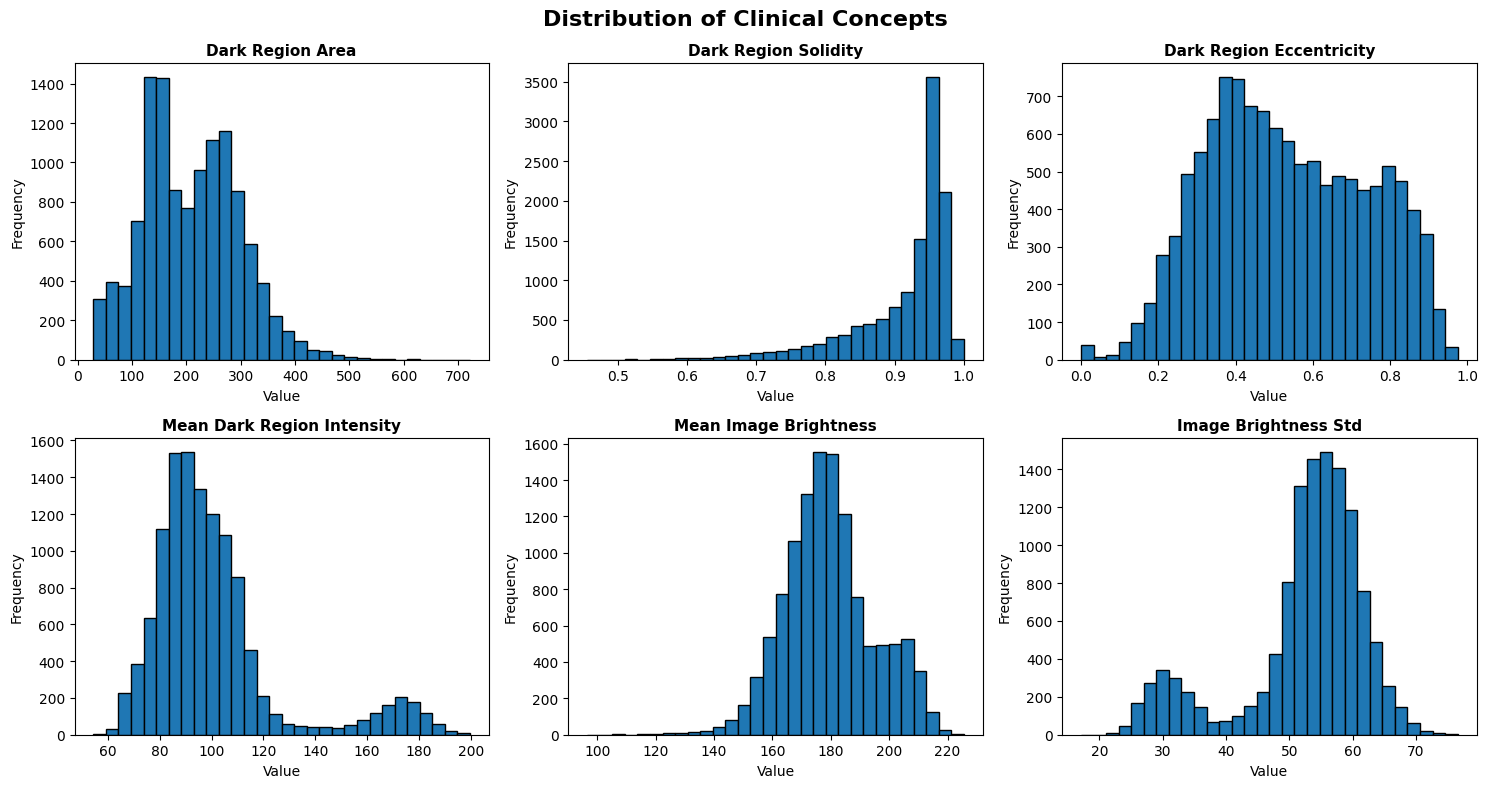

In [25]:
# ============================================================
# Feature Distributions
# ============================================================

fig, axes = plt.subplots(

    2,

    3,

    figsize=(15, 8)

)

for axis, concept in zip(

    axes.ravel(),

    CONCEPT_NAMES

):

    axis.hist(

        concept_train_df[concept],

        bins=30,

        edgecolor="black"

    )

    axis.set_title(

        concept.replace("_", " ").title(),

        fontsize=11,

        fontweight="bold"

    )

    axis.set_xlabel("Value")

    axis.set_ylabel("Frequency")

plt.suptitle(

    "Distribution of Clinical Concepts",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "concept_feature_distributions",

    CONCEPT_FIGURE_DIR

)

plt.show()

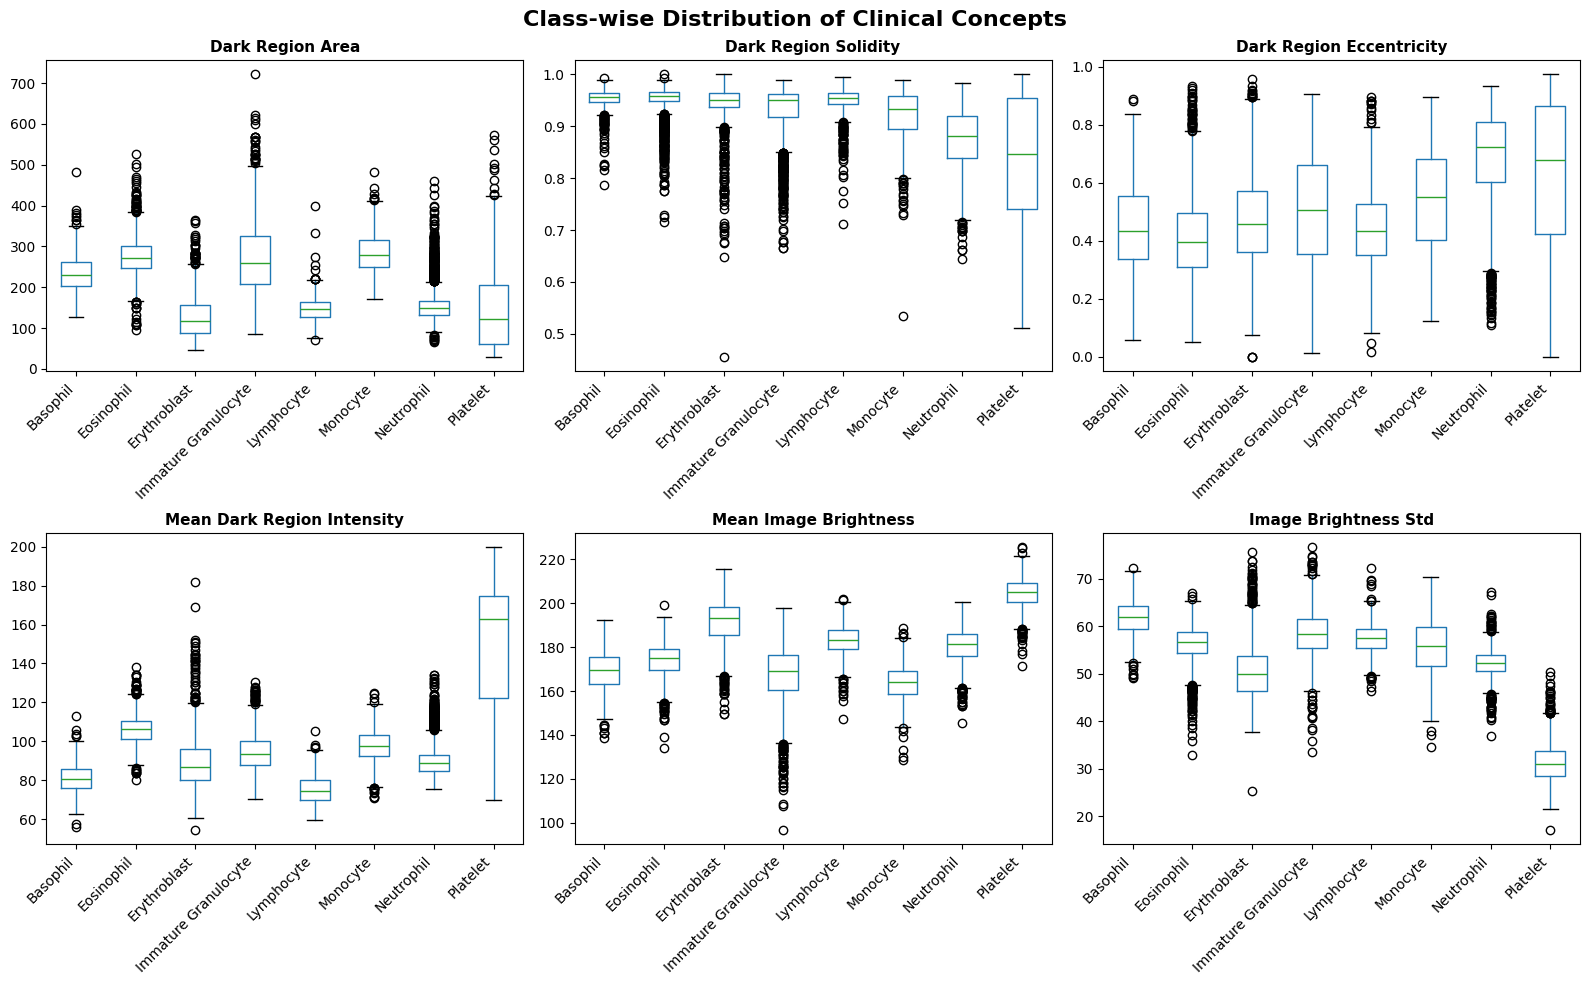

In [26]:
# ============================================================
# Class-wise Boxplots
# ============================================================

fig, axes = plt.subplots(

    2,

    3,

    figsize=(16, 10)

)

for axis, concept in zip(

    axes.ravel(),

    CONCEPT_NAMES

):

    concept_train_df.boxplot(

        column=concept,

        by="label",

        ax=axis,

        grid=False

    )

    axis.set_title(

        concept.replace("_", " ").title(),

        fontsize=11,

        fontweight="bold"

    )

    axis.set_xlabel("")

    axis.set_xticklabels(

        CLASS_NAMES,

        rotation=45,

        ha="right"

    )

plt.suptitle("")

plt.tight_layout()

plt.subplots_adjust(top=0.93)

plt.gcf().suptitle(

    "Class-wise Distribution of Clinical Concepts",

    fontsize=16,

    fontweight="bold"

)

save_figure(

    "classwise_concept_boxplots",

    CONCEPT_FIGURE_DIR

)

plt.show()

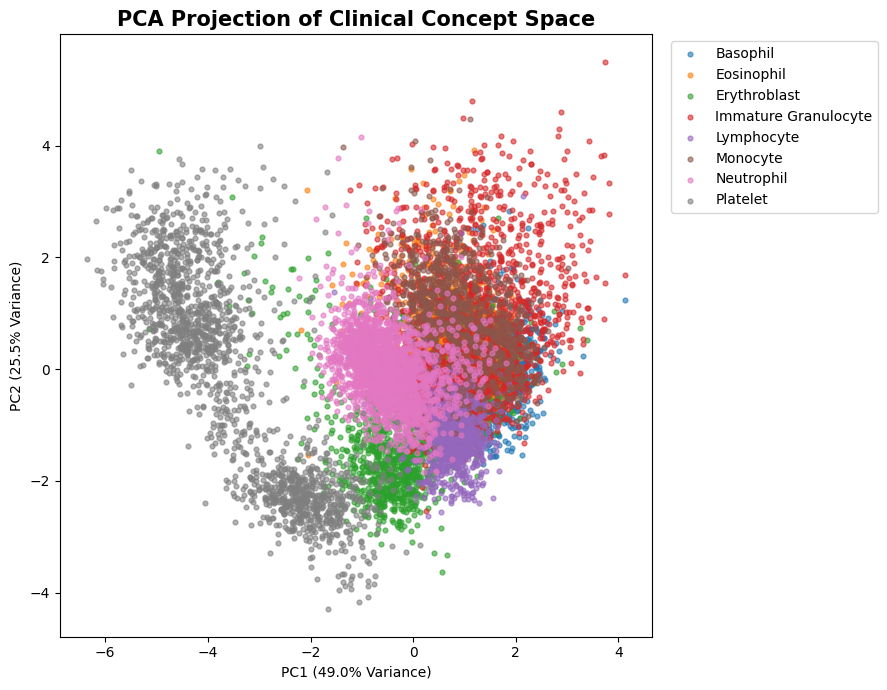

Explained Variance
PC1 : 0.490
PC2 : 0.255
Total : 0.745


In [27]:
# ============================================================
# PCA Visualization
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Standardize for PCA only
# ------------------------------------------------------------

pca_scaler = StandardScaler()

concepts_scaled = pca_scaler.fit_transform(

    concept_train_df[CONCEPT_NAMES]

)

# ------------------------------------------------------------
# PCA Projection
# ------------------------------------------------------------

pca = PCA(

    n_components=2,

    random_state=RANDOM_STATE

)

principal_components = pca.fit_transform(

    concepts_scaled

)

pca_dataframe = pd.DataFrame({

    "PC1": principal_components[:, 0],

    "PC2": principal_components[:, 1],

    "Class": concept_train_df["label"]

})

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for class_index, class_name in enumerate(CLASS_NAMES):

    subset = pca_dataframe[

        pca_dataframe["Class"] == class_index

    ]

    plt.scatter(

        subset["PC1"],

        subset["PC2"],

        s=12,

        alpha=0.6,

        label=class_name

    )

plt.xlabel(

    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)"

)

plt.ylabel(

    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)"

)

plt.title(

    "PCA Projection of Clinical Concept Space",

    fontsize=15,

    fontweight="bold"

)

plt.legend(

    bbox_to_anchor=(1.02, 1),

    loc="upper left"

)

plt.tight_layout()

save_figure(

    "concept_pca_visualization",

    CONCEPT_FIGURE_DIR

)

plt.show()

print("=" * 70)
print("Explained Variance")
print("=" * 70)

print(f"PC1 : {pca.explained_variance_ratio_[0]:.3f}")

print(f"PC2 : {pca.explained_variance_ratio_[1]:.3f}")

print(f"Total : {pca.explained_variance_ratio_.sum():.3f}")

In [28]:
# ============================================================
# Save Concept Datasets
# ============================================================

save_csv(

    concept_train_df,

    "concept_train_dataset",

    CONCEPT_CSV_DIR

)

save_csv(

    concept_validation_df,

    "concept_validation_dataset",

    CONCEPT_CSV_DIR

)

save_csv(

    concept_test_df,

    "concept_test_dataset",

    CONCEPT_CSV_DIR

)

print("=" * 70)
print("Concept Datasets Saved Successfully")
print("=" * 70)

Concept Datasets Saved Successfully


In [29]:
# ============================================================
# Standardize Clinical Concepts
# ============================================================

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Separate Features and Labels
# ------------------------------------------------------------

X_train = concept_train_df[CONCEPT_NAMES]

y_train = concept_train_df["label"]

X_validation = concept_validation_df[CONCEPT_NAMES]

y_validation = concept_validation_df["label"]

X_test = concept_test_df[CONCEPT_NAMES]

y_test = concept_test_df["label"]

# ------------------------------------------------------------
# Fit Scaler on Training Data Only
# ------------------------------------------------------------

concept_scaler = StandardScaler()

concept_scaler.fit(

    X_train

)

# ------------------------------------------------------------
# Transform All Splits
# ------------------------------------------------------------

X_train = concept_scaler.transform(

    X_train

)

X_validation = concept_scaler.transform(

    X_validation

)

X_test = concept_scaler.transform(

    X_test

)

print("=" * 70)
print("Clinical Concepts Standardized")
print("=" * 70)

print()

print("Training Shape   :", X_train.shape)

print("Validation Shape :", X_validation.shape)

print("Test Shape       :", X_test.shape)

Clinical Concepts Standardized

Training Shape   : (11959, 6)
Validation Shape : (1712, 6)
Test Shape       : (3421, 6)


In [30]:
# ============================================================
# Verify Clinical Concept Standardization
# ============================================================

# ------------------------------------------------------------
# Compute Mean and Standard Deviation
# ------------------------------------------------------------

standardization_summary = pd.DataFrame(

    {

        "Train Mean":

            np.mean(

                X_train,

                axis=0

            ),

        "Validation Mean":

            np.mean(

                X_validation,

                axis=0

            ),

        "Test Mean":

            np.mean(

                X_test,

                axis=0

            ),

        "Train Std":

            np.std(

                X_train,

                axis=0

            ),

        "Validation Std":

            np.std(

                X_validation,

                axis=0

            ),

        "Test Std":

            np.std(

                X_test,

                axis=0

            )

    },

    index=CONCEPT_NAMES

)

print("=" * 70)
print("Clinical Concept Standardization Verification")
print("=" * 70)

display(

    standardization_summary.round(4)

)

print()

# ------------------------------------------------------------
# Training Set Verification
# ------------------------------------------------------------

train_mean_ok = np.allclose(

    np.mean(

        X_train,

        axis=0

    ),

    0,

    atol=1e-6

)

train_std_ok = np.allclose(

    np.std(

        X_train,

        axis=0

    ),

    1,

    atol=1e-6

)

if train_mean_ok and train_std_ok:

    print(

        "✓ Training features have zero mean and unit variance."

    )

else:

    print(

        "⚠ Training standardization verification failed."

    )

print()

print(

    "Note: Validation and test statistics are expected to "

    "differ slightly because the scaler was fitted only on "

    "the training data."

)

Clinical Concept Standardization Verification


,Train Mean,Validation Mean,Test Mean,Train Std,Validation Std,Test Std
dark_region_area,0.0,-0.0015,0.0026,1.0,1.0020,0.9990
dark_region_solidity,0.0,-0.0248,-0.0118,1.0,1.0047,1.0252
dark_region_eccentricity,0.0,0.0074,-0.0109,1.0,0.9943,1.0151
mean_dark_region_intensity,-0.0,0.0146,0.0001,1.0,0.9921,1.0021
mean_image_brightness,0.0,0.0026,-0.0049,1.0,0.9706,0.9961
image_brightness_std,0.0,-0.0142,0.0070,1.0,0.9894,1.0024



✓ Training features have zero mean and unit variance.

Note: Validation and test statistics are expected to differ slightly because the scaler was fitted only on the training data.


In [31]:
# ============================================================
# Build Concept MLP
# ============================================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input
)

concept_mlp = Sequential(

    [

        # ----------------------------------------------------
        # Input Layer
        # ----------------------------------------------------

        Input(

            shape=(len(CONCEPT_NAMES),)

        ),

        # ----------------------------------------------------
        # Hidden Layer 1
        # ----------------------------------------------------

        Dense(

            32,

            activation="relu"

        ),

        Dropout(

            0.30

        ),

        # ----------------------------------------------------
        # Hidden Layer 2
        # ----------------------------------------------------

        Dense(

            16,

            activation="relu"

        ),

        Dropout(

            0.30

        ),

        # ----------------------------------------------------
        # Output Layer
        # ----------------------------------------------------

        Dense(

            len(CLASS_NAMES),

            activation="softmax"

        )

    ]

)

print("=" * 70)
print("Concept MLP Architecture")
print("=" * 70)

concept_mlp.summary()

Concept MLP Architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 888 (3.47 KB)

 Trainable params: 888 (3.47 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ============================================================
# Compile Concept MLP
# ============================================================

from tensorflow.keras.optimizers import Adam

concept_mlp.compile(

    optimizer=Adam(

        learning_rate=0.001

    ),

    loss="sparse_categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)

print("=" * 70)
print("Concept MLP Compiled Successfully")
print("=" * 70)

print()

print("Optimizer      : Adam")

print("Learning Rate  : 0.001")

print("Loss Function  : Sparse Categorical Crossentropy")

print("Evaluation     : Accuracy")

Concept MLP Compiled Successfully

Optimizer      : Adam
Learning Rate  : 0.001
Loss Function  : Sparse Categorical Crossentropy
Evaluation     : Accuracy


In [33]:
# ============================================================
# Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ReduceLROnPlateau,

    ModelCheckpoint

)

# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

# ------------------------------------------------------------
# Learning Rate Scheduler
# ------------------------------------------------------------

learning_rate_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

# ------------------------------------------------------------
# Model Checkpoint
# ------------------------------------------------------------

best_model_checkpoint = ModelCheckpoint(

    filepath=os.path.join(

        MODEL_DIR,

        "concept_mlp_best.keras"

    ),

    monitor="val_loss",

    save_best_only=True,

    mode="min",

    verbose=1

)

# ------------------------------------------------------------
# Callback List
# ------------------------------------------------------------

training_callbacks = [

    early_stopping,

    learning_rate_scheduler,

    best_model_checkpoint

]

print("=" * 70)
print("Training Callbacks Configured")
print("=" * 70)

print()

print("• EarlyStopping")

print("    Monitor   : val_loss")

print("    Patience  :", early_stopping.patience)

print()

print("• ReduceLROnPlateau")

print("    Factor    : 0.5")

print("    Patience  :", learning_rate_scheduler.patience)

print()

print("• ModelCheckpoint")

print("    Monitor   : val_loss")

print("    Save Best : True")

Training Callbacks Configured

• EarlyStopping
    Monitor   : val_loss
    Patience  : 10

• ReduceLROnPlateau
    Factor    : 0.5
    Patience  : 5

• ModelCheckpoint
    Monitor   : val_loss
    Save Best : True


In [34]:
# ============================================================
# Train Concept MLP
# ============================================================

NUM_EPOCHS = 100

BATCH_SIZE = 32

history = concept_mlp.fit(

    X_train,

    y_train,

    validation_data=(

        X_validation,

        y_validation

    ),

    epochs=NUM_EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=training_callbacks,

    verbose=1

)

print("=" * 70)
print("Concept MLP Training Complete")
print("=" * 70)

print()

print(

    f"Best Validation Accuracy : "

    f"{max(history.history['val_accuracy']):.4f}"

)

print(

    f"Best Validation Loss : "

    f"{min(history.history['val_loss']):.4f}"

)

Epoch 1/100
366/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3168 - loss: 1.8417
Epoch 1: val_loss improved from None to 1.05561, saving model to ConceptScope/models/concept_mlp_best.keras

Epoch 1: finished saving model to ConceptScope/models/concept_mlp_best.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4290 - loss: 1.5827 - val_accuracy: 0.6665 - val_loss: 1.0556 - learning_rate: 0.0010
Epoch 2/100
357/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5683 - loss: 1.1718
Epoch 2: val_loss improved from 1.05561 to 0.86355, saving model to ConceptScope/models/concept_mlp_best.keras

Epoch 2: finished saving model to ConceptScope/models/concept_mlp_best.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5835 - loss: 1.1331 - val_accuracy: 0.7056 - val_loss: 0.8636 - learning_rate: 0.0010
Epoch 3/100
361/374 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6149 - loss: 1.0538
Epoch 3: val_loss improved from 0.86355 to 0.81085, saving model to ConceptScope/m

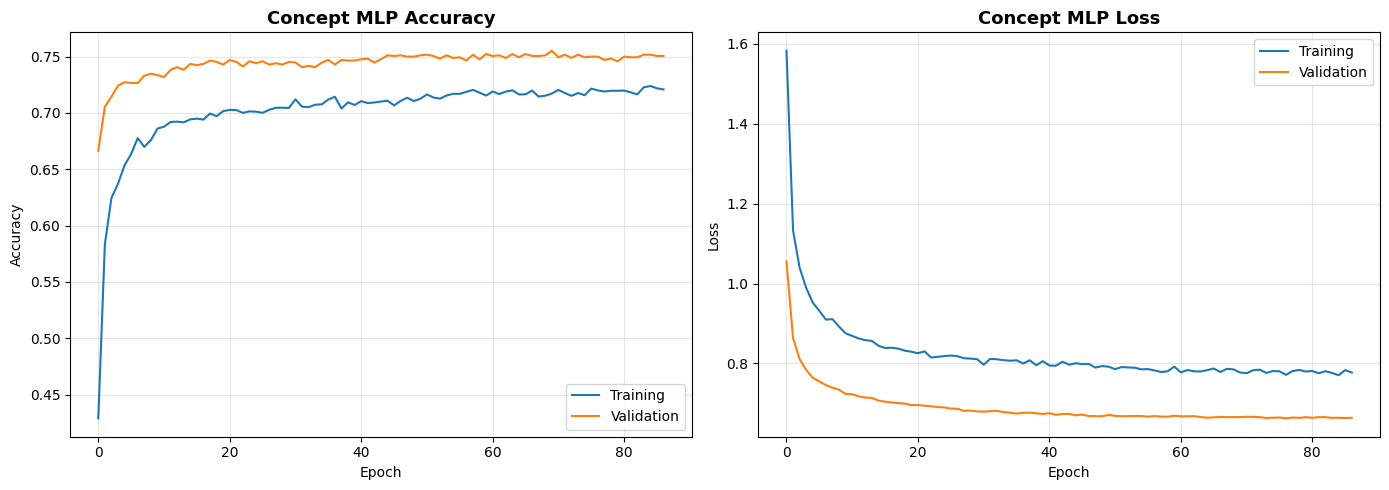

In [35]:
# ============================================================
# Concept MLP Training Curves
# ============================================================

fig, axes = plt.subplots(

    1,

    2,

    figsize=(14, 5)

)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

axes[0].plot(

    history.history["accuracy"],

    label="Training"

)

axes[0].plot(

    history.history["val_accuracy"],

    label="Validation"

)

axes[0].set_title(

    "Concept MLP Accuracy",

    fontsize=13,

    fontweight="bold"

)

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Accuracy")

axes[0].legend()

axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

axes[1].plot(

    history.history["loss"],

    label="Training"

)

axes[1].plot(

    history.history["val_loss"],

    label="Validation"

)

axes[1].set_title(

    "Concept MLP Loss",

    fontsize=13,

    fontweight="bold"

)

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("Loss")

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.tight_layout()

save_figure(

    "concept_mlp_training_curves",

    CONCEPT_FIGURE_DIR

)

plt.show()

In [36]:
# ============================================================
# Load Best Concept MLP
# ============================================================

from tensorflow.keras.models import load_model

concept_mlp = load_model(

    os.path.join(

        MODEL_DIR,

        "concept_mlp_best.keras"

    )

)

print("=" * 70)
print("Best Concept MLP Loaded")
print("=" * 70)

concept_mlp.summary()

Best Concept MLP Loaded


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,666 (10.42 KB)

 Trainable params: 888 (3.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,778 (6.95 KB)

In [37]:
# ============================================================
# Monte Carlo Dropout Forward Passes
# ============================================================

NUM_MC_SAMPLES = 30

mc_prediction_list = []

print("=" * 70)
print("Running Monte Carlo Dropout Inference")
print("=" * 70)

for _ in tqdm(

    range(NUM_MC_SAMPLES),

    desc="MC Forward Passes"

):

    stochastic_prediction = concept_mlp(

        X_test,

        training=True

    ).numpy()

    mc_prediction_list.append(

        stochastic_prediction

    )

# ------------------------------------------------------------
# Stack Predictions
# ------------------------------------------------------------

mc_prediction_tensor = np.stack(

    mc_prediction_list,

    axis=0

)

print()

print("=" * 70)
print("Monte Carlo Inference Complete")
print("=" * 70)

print()

print(

    "Prediction Tensor Shape :",

    mc_prediction_tensor.shape

)

print(

    "Monte Carlo Samples     :",

    NUM_MC_SAMPLES

)

Running Monte Carlo Dropout Inference


MC Forward Passes:   0%|          | 0/30 [00:00<?, ?it/s]


Monte Carlo Inference Complete

Prediction Tensor Shape : (30, 3421, 8)
Monte Carlo Samples     : 30


In [38]:
# ============================================================
# Compute Predictive Statistics
# ============================================================

# ------------------------------------------------------------
# Mean Predictive Distribution
# ------------------------------------------------------------

mean_prediction = np.mean(

    mc_prediction_tensor,

    axis=0

)

# ------------------------------------------------------------
# Final Predicted Class
# ------------------------------------------------------------

predicted_classes = np.argmax(

    mean_prediction,

    axis=1

)

print("=" * 70)
print("Predictive Statistics Computed")
print("=" * 70)

print()

print(

    "Mean Prediction Shape           :",

    mean_prediction.shape

)

print(

    "Predicted Classes Shape         :",

    predicted_classes.shape

)

Predictive Statistics Computed

Mean Prediction Shape           : (3421, 8)
Predicted Classes Shape         : (3421,)


In [39]:
# ============================================================
# Concept MLP Performance Evaluation
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix

)

# ------------------------------------------------------------
# Overall Accuracy
# ------------------------------------------------------------

test_accuracy = accuracy_score(

    raw_test_labels,

    predicted_classes

)

print("=" * 70)
print("Concept MLP Test Performance")
print("=" * 70)

print()

print(

    f"Overall Test Accuracy : {test_accuracy:.4f}"

)

print()

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("=" * 70)
print("Classification Report")
print("=" * 70)

print()

print(

    classification_report(

        raw_test_labels,

        predicted_classes,

        target_names=CLASS_NAMES,

        digits=4

    )

)

Concept MLP Test Performance

Overall Test Accuracy : 0.7568

Classification Report

                      precision    recall  f1-score   support

            Basophil     0.6342    0.6680    0.6507       244
          Eosinophil     0.7001    0.8718    0.7766       624
        Erythroblast     0.9091    0.7074    0.7957       311
Immature Granulocyte     0.5513    0.5751    0.5630       579
          Lymphocyte     0.7967    0.7901    0.7934       243
            Monocyte     0.5894    0.3134    0.4092       284
          Neutrophil     0.8663    0.8754    0.8708       666
            Platelet     0.9769    0.9894    0.9831       470

            accuracy                         0.7568      3421
           macro avg     0.7530    0.7238    0.7303      3421
        weighted avg     0.7573    0.7568    0.7506      3421



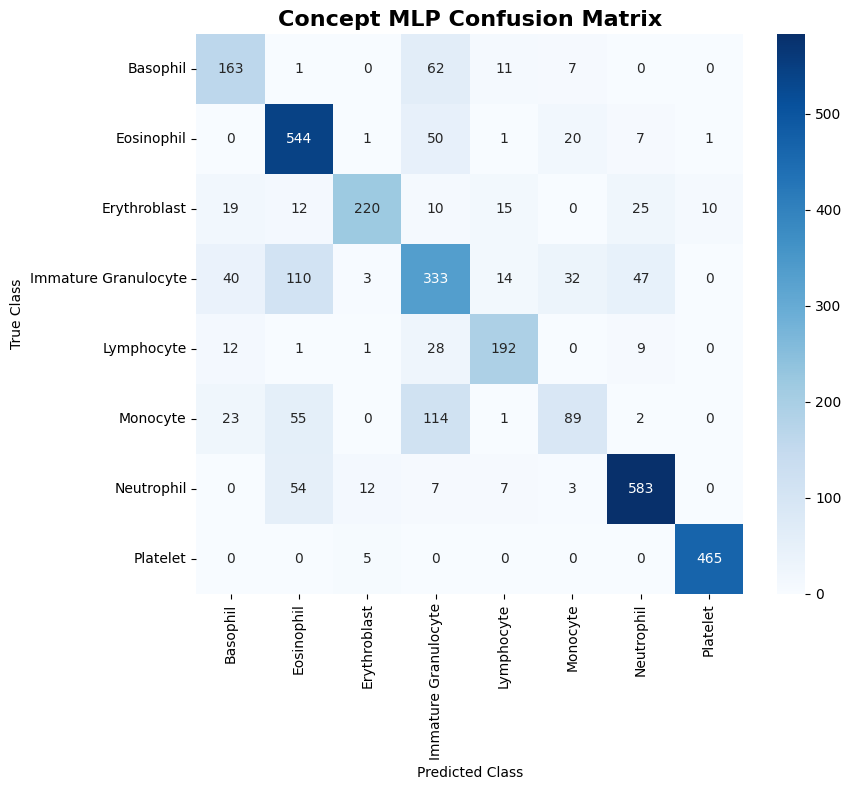

In [40]:
# ============================================================
# Confusion Matrix
# ============================================================

import seaborn as sns

confusion = confusion_matrix(

    raw_test_labels,

    predicted_classes

)

plt.figure(

    figsize=(9, 8)

)

sns.heatmap(

    confusion,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.title(

    "Concept MLP Confusion Matrix",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.tight_layout()

save_figure(

    "concept_mlp_confusion_matrix",

    CONCEPT_FIGURE_DIR

)

plt.show()

In [41]:
# ============================================================
# Save Classification Results
# ============================================================

classification_results = pd.DataFrame(

    classification_report(

        raw_test_labels,

        predicted_classes,

        target_names=CLASS_NAMES,

        output_dict=True

    )

).transpose()

confusion_matrix_df = pd.DataFrame(

    confusion,

    index=CLASS_NAMES,

    columns=CLASS_NAMES

)

save_csv(

    classification_results,

    "classification_report",

    PREDICTION_CSV_DIR

)

save_csv(

    confusion_matrix_df,

    "confusion_matrix",

    PREDICTION_CSV_DIR

)

print("=" * 70)
print("Classification Results Saved")
print("=" * 70)

Classification Results Saved


In [42]:
# ============================================================
# Compute Predictive Statistics
# ============================================================

EPSILON = 1e-10

# ------------------------------------------------------------
# Mean Predictive Distribution
# ------------------------------------------------------------

mean_prediction = np.mean(

    mc_prediction_tensor,

    axis=0

)

# ------------------------------------------------------------
# Final Predicted Class
# ------------------------------------------------------------

predicted_classes = np.argmax(

    mean_prediction,

    axis=1

)

# ------------------------------------------------------------
# Predictive Entropy
# Overall Predictive Uncertainty
# ------------------------------------------------------------

predictive_entropy = -np.sum(

    mean_prediction *

    np.log(

        mean_prediction + EPSILON

    ),

    axis=1

)

print("=" * 70)
print("Predictive Statistics Computed")
print("=" * 70)

print()

print(

    "Mean Prediction Shape      :",

    mean_prediction.shape

)

print(

    "Predicted Classes Shape    :",

    predicted_classes.shape

)

print(

    "Predictive Entropy Shape   :",

    predictive_entropy.shape

)

Predictive Statistics Computed

Mean Prediction Shape      : (3421, 8)
Predicted Classes Shape    : (3421,)
Predictive Entropy Shape   : (3421,)


In [43]:
# ============================================================
# Predictive Entropy Summary Statistics
# ============================================================

predictive_entropy_statistics = pd.DataFrame({

    "Statistic": [

        "Minimum",

        "Maximum",

        "Mean",

        "Median",

        "Standard Deviation"

    ],

    "Predictive Entropy": [

        np.min(

            predictive_entropy

        ),

        np.max(

            predictive_entropy

        ),

        np.mean(

            predictive_entropy

        ),

        np.median(

            predictive_entropy

        ),

        np.std(

            predictive_entropy

        )

    ]

})

print("=" * 70)
print("Predictive Entropy Summary Statistics")
print("=" * 70)

display(

    predictive_entropy_statistics

)

save_csv(

    predictive_entropy_statistics,

    "predictive_entropy_statistics",

    UNCERTAINTY_CSV_DIR

)

Predictive Entropy Summary Statistics


,Statistic,Predictive Entropy
0,Minimum,0.004195
1,Maximum,1.724712
2,Mean,0.923217
3,Median,1.013406
4,Standard Deviation,0.461065


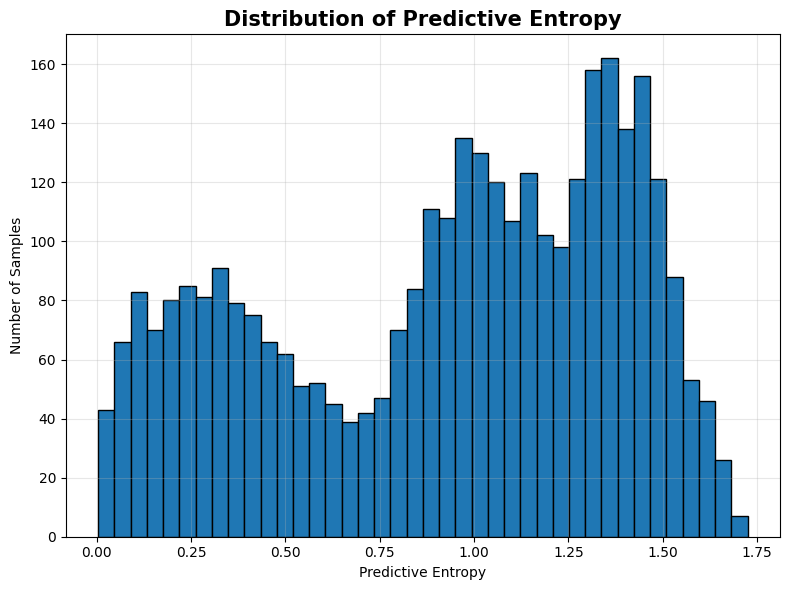

In [44]:
# ============================================================
# Predictive Entropy Distribution
# ============================================================

plt.figure(

    figsize=(8, 6)

)

plt.hist(

    predictive_entropy,

    bins=40,

    edgecolor="black"

)

plt.title(

    "Distribution of Predictive Entropy",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel(

    "Predictive Entropy"

)

plt.ylabel(

    "Number of Samples"

)

plt.grid(

    alpha=0.3

)

plt.tight_layout()

save_figure(

    "predictive_entropy_distribution",

    UNCERTAINTY_FIGURE_DIR

)

plt.show()

In [45]:
# ============================================================
# Representative Certain and Uncertain Samples Per Class
# ============================================================

certain_indices = []

uncertain_indices = []

for class_index in range(len(CLASS_NAMES)):

    # --------------------------------------------------------
    # Samples belonging to current class
    # --------------------------------------------------------

    class_indices = np.where(

        raw_test_labels == class_index

    )[0]

    class_entropy = predictive_entropy[

        class_indices

    ]

    # --------------------------------------------------------
    # Lowest Entropy Sample
    # --------------------------------------------------------

    certain_indices.append(

        class_indices[

            np.argmin(

                class_entropy

            )

        ]

    )

    # --------------------------------------------------------
    # Highest Entropy Sample
    # --------------------------------------------------------

    uncertain_indices.append(

        class_indices[

            np.argmax(

                class_entropy

            )

        ]

    )

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

entropy_examples = pd.DataFrame({

    "Class": CLASS_NAMES,

    "Certain Index": certain_indices,

    "Certain Entropy": predictive_entropy[

        certain_indices

    ],

    "Uncertain Index": uncertain_indices,

    "Uncertain Entropy": predictive_entropy[

        uncertain_indices

    ]

})

print("=" * 70)
print("Representative Certain and Uncertain Samples")
print("=" * 70)

display(

    entropy_examples

)

save_csv(

    entropy_examples,

    "representative_entropy_samples",

    UNCERTAINTY_CSV_DIR

)

Representative Certain and Uncertain Samples


,Class,Certain Index,Certain Entropy,Uncertain Index,Uncertain Entropy
0,Basophil,3045,0.794600,3152,1.693635
1,Eosinophil,1174,0.672067,308,1.672038
2,Erythroblast,2857,0.103271,320,1.708808
3,Immature Granulocyte,2434,0.360056,1476,1.702111
4,Lymphocyte,2786,0.407699,802,1.682953
5,Monocyte,1066,0.829721,372,1.724712
6,Neutrophil,2716,0.098814,1499,1.610755
7,Platelet,3067,0.004195,3205,0.864673


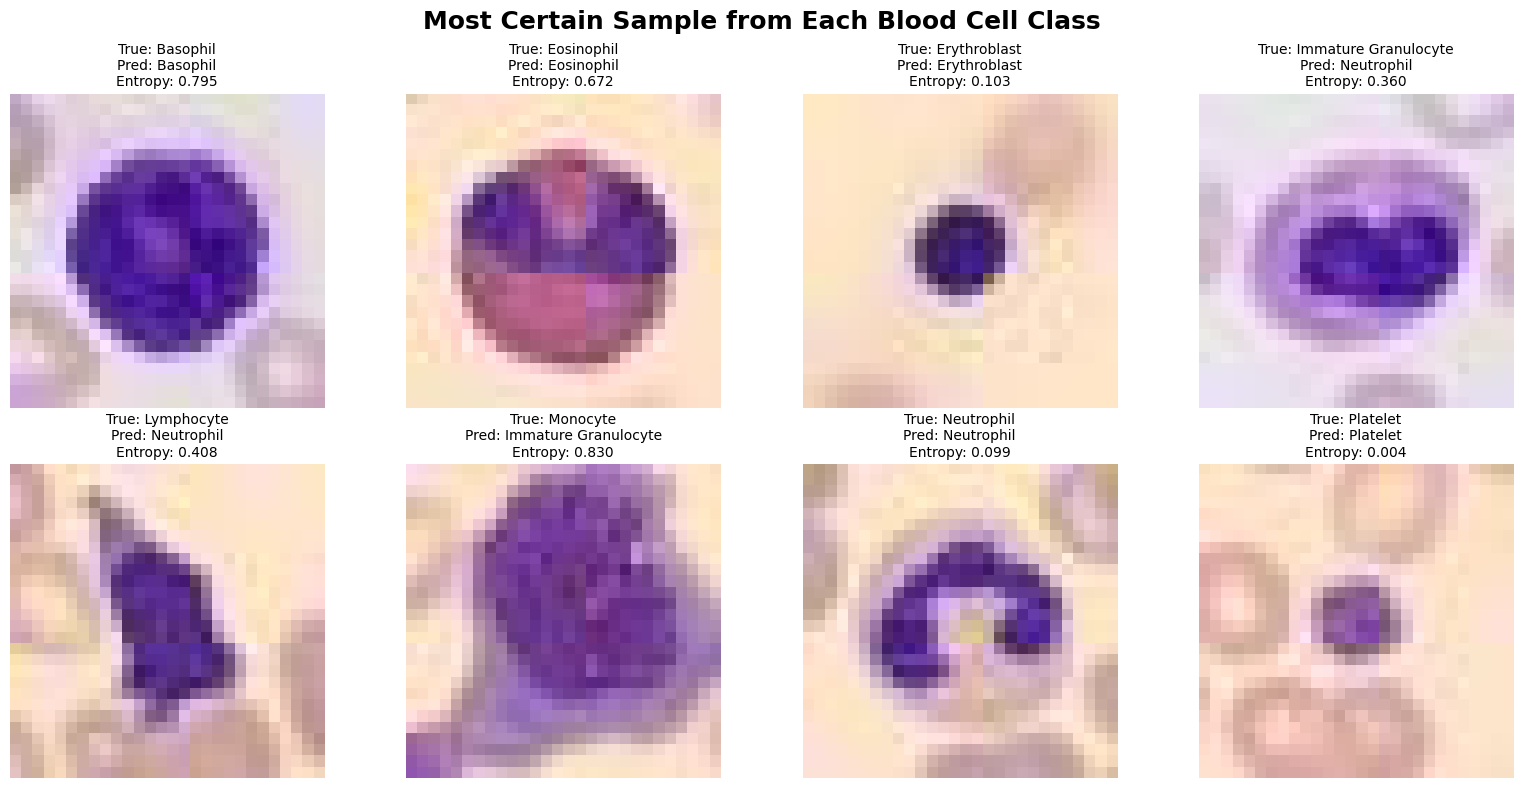

In [46]:
# ============================================================
# Most Certain Sample from Each Class
# ============================================================

fig, axes = plt.subplots(

    2,

    4,

    figsize=(16, 8)

)

for ax, idx in zip(

    axes.ravel(),

    certain_indices

):

    image = raw_test_images[idx]

    true_label = CLASS_NAMES[

        raw_test_labels[idx]

    ]

    predicted_label = CLASS_NAMES[

        predicted_classes[idx]

    ]

    entropy = predictive_entropy[idx]

    ax.imshow(

        image

    )

    ax.set_title(

        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Entropy: {entropy:.3f}",

        fontsize=10

    )

    ax.axis("off")

plt.suptitle(

    "Most Certain Sample from Each Blood Cell Class",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "most_certain_per_class",

    UNCERTAINTY_FIGURE_DIR

)

plt.show()

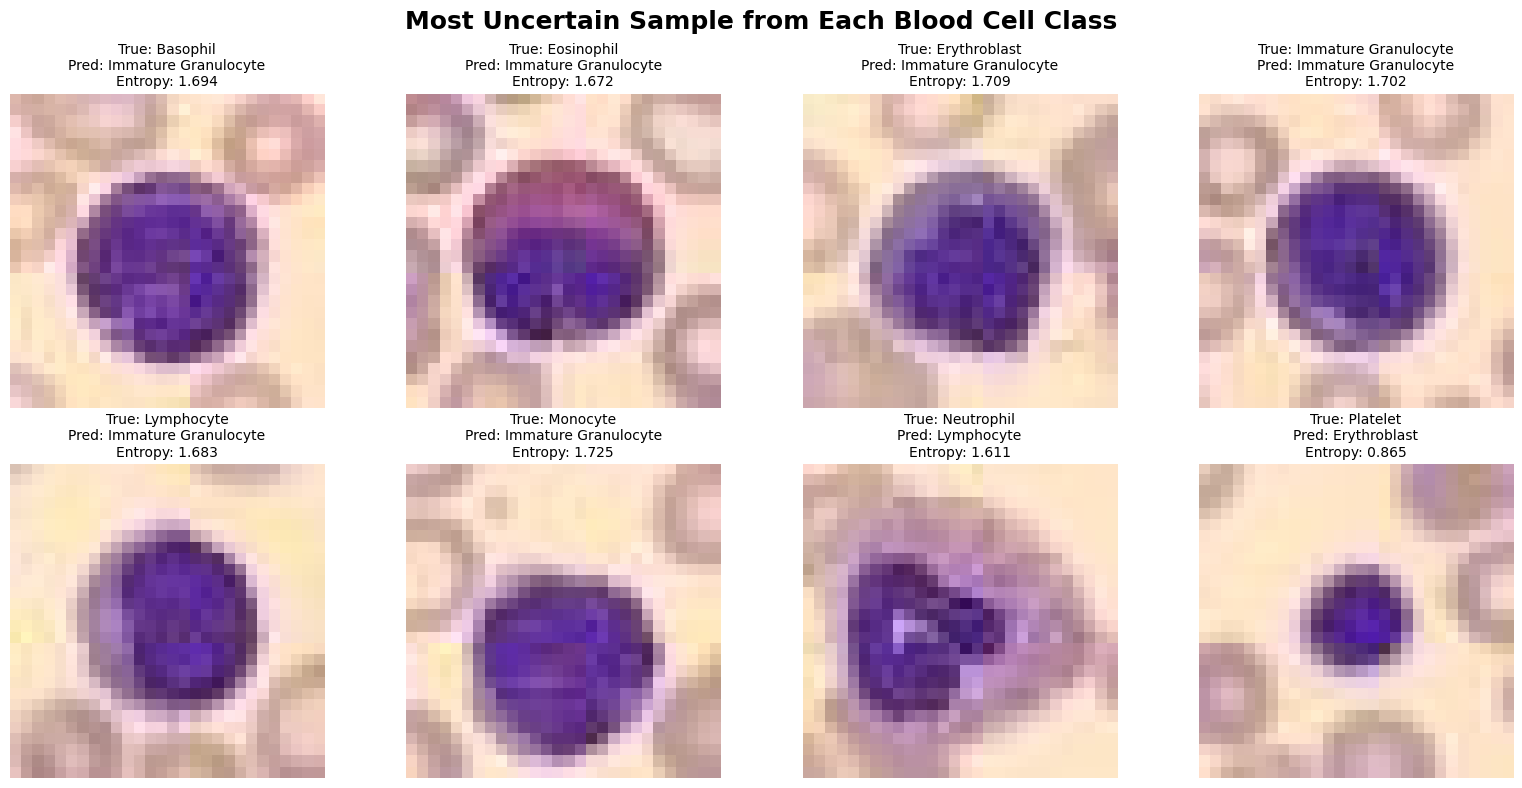

In [47]:
# ============================================================
# Most Uncertain Sample from Each Class
# ============================================================

fig, axes = plt.subplots(

    2,

    4,

    figsize=(16, 8)

)

for ax, idx in zip(

    axes.ravel(),

    uncertain_indices

):

    image = raw_test_images[idx]

    true_label = CLASS_NAMES[

        raw_test_labels[idx]

    ]

    predicted_label = CLASS_NAMES[

        predicted_classes[idx]

    ]

    entropy = predictive_entropy[idx]

    ax.imshow(

        image

    )

    ax.set_title(

        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Entropy: {entropy:.3f}",

        fontsize=10

    )

    ax.axis("off")

plt.suptitle(

    "Most Uncertain Sample from Each Blood Cell Class",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "most_uncertain_per_class",

    UNCERTAINTY_FIGURE_DIR

)

plt.show()

In [48]:
# ============================================================
# SHAP Prediction Wrapper Functions
# ============================================================

EPSILON = 1e-10


# ============================================================
# Predicted Class Probability (MC Dropout)
# ============================================================

def prediction_probability_function(concepts):

    # Ensure deterministic evaluations for KernelSHAP

    tf.keras.utils.set_random_seed(SHAP_RANDOM_SEED)

    mc_predictions = []

    for _ in range(NUM_MC_SAMPLES):

        probabilities = concept_mlp(

            concepts,

            training=True

        ).numpy()

        mc_predictions.append(

            probabilities

        )

    mc_predictions = np.stack(

        mc_predictions,

        axis=0

    )

    mean_prediction = np.mean(

        mc_predictions,

        axis=0

    )

    predicted_classes = np.argmax(

        mean_prediction,

        axis=1

    )

    return mean_prediction[

        np.arange(

            len(mean_prediction)

        ),

        predicted_classes

    ]


# ============================================================
# Predictive Entropy (MC Dropout)
# ============================================================

def predictive_entropy_function(concepts):

    # Ensure deterministic evaluations for KernelSHAP

    tf.keras.utils.set_random_seed(SHAP_RANDOM_SEED)

    mc_predictions = []

    for _ in range(NUM_MC_SAMPLES):

        probabilities = concept_mlp(

            concepts,

            training=True

        ).numpy()

        mc_predictions.append(

            probabilities

        )

    mc_predictions = np.stack(

        mc_predictions,

        axis=0

    )

    mean_prediction = np.mean(

        mc_predictions,

        axis=0

    )

    predictive_entropy = -np.sum(

        mean_prediction *

        np.log(

            mean_prediction + EPSILON

        ),

        axis=1

    )

    return predictive_entropy

In [49]:
# ============================================================
# Verify SHAP Wrapper Functions
# ============================================================

NUM_TEST_SAMPLES = 5

test_concepts = X_test[:NUM_TEST_SAMPLES]

# ------------------------------------------------------------
# Prediction Wrapper
# ------------------------------------------------------------

prediction_outputs = prediction_probability_function(

    test_concepts

)

# ------------------------------------------------------------
# Predictive Entropy Wrapper
# ------------------------------------------------------------

entropy_outputs = predictive_entropy_function(

    test_concepts

)

print("=" * 70)
print("SHAP Wrapper Verification")
print("=" * 70)

print()

print("Prediction Output Shape :", prediction_outputs.shape)

print("Entropy Output Shape    :", entropy_outputs.shape)

print()

print("Prediction Probabilities")

print(prediction_outputs)

print()

print("Predictive Entropies")

print(entropy_outputs)

print()

assert prediction_outputs.shape == (NUM_TEST_SAMPLES,)

assert entropy_outputs.shape == (NUM_TEST_SAMPLES,)

assert np.all(prediction_outputs >= 0)

assert np.all(prediction_outputs <= 1)

assert np.all(entropy_outputs >= 0)

assert np.all(entropy_outputs <= np.log(len(CLASS_NAMES)) + 1e-6)

print("✓ Wrapper functions verified successfully.")

SHAP Wrapper Verification

Prediction Output Shape : (5,)
Entropy Output Shape    : (5,)

Prediction Probabilities
[0.59532064 0.5629345  0.7144029  0.83959633 0.45590666]

Predictive Entropies
[1.1222851  1.271806   1.0010762  0.65304536 1.3098316 ]

✓ Wrapper functions verified successfully.


In [50]:
# ============================================================
# SHAP Configuration
# ============================================================

BACKGROUND_SIZE = 100

EXPLANATION_SIZE = len(X_test)

SHAP_RANDOM_STATE = RANDOM_STATE

print("=" * 70)
print("SHAP Configuration")
print("=" * 70)

print()

print("Background Samples :", BACKGROUND_SIZE)

print("Explanation Samples:", EXPLANATION_SIZE)

SHAP Configuration

Background Samples : 100
Explanation Samples: 3421


In [51]:
# ============================================================
# SHAP Background and Explanation Dataset
# ============================================================

np.random.seed(

    SHAP_RANDOM_STATE

)

# ------------------------------------------------------------
# Background Dataset
# ------------------------------------------------------------

background_indices = np.random.choice(

    len(X_train),

    BACKGROUND_SIZE,

    replace=False

)

background_data = X_train[

    background_indices

]

# ------------------------------------------------------------
# Explanation Dataset
# ------------------------------------------------------------

explanation_data = X_test[

    :EXPLANATION_SIZE

]

print("=" * 70)
print("SHAP Dataset Prepared")
print("=" * 70)

print()

print(

    "Background Shape :",

    background_data.shape

)

print(

    "Explanation Shape:",

    explanation_data.shape

)

SHAP Dataset Prepared

Background Shape : (100, 6)
Explanation Shape: (3421, 6)


In [52]:
# ============================================================
# Prediction KernelSHAP Explainer
# ============================================================

prediction_explainer = shap.KernelExplainer(

    prediction_probability_function,

    background_data

)

print("=" * 70)
print("Prediction KernelSHAP Explainer Created")
print("=" * 70)

Prediction KernelSHAP Explainer Created


In [53]:
# ============================================================
# Compute Prediction SHAP Values
# ============================================================

prediction_shap_values = prediction_explainer.shap_values(

    explanation_data

)

print("=" * 70)
print("Prediction SHAP Computation Complete")
print("=" * 70)

print()

print(

    "Prediction SHAP Shape:",

    np.array(

        prediction_shap_values

    ).shape

)

  0%|          | 0/3421 [00:00<?, ?it/s]

Prediction SHAP Computation Complete

Prediction SHAP Shape: (3421, 6)


/tmp/ipykernel_883/3405525004.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


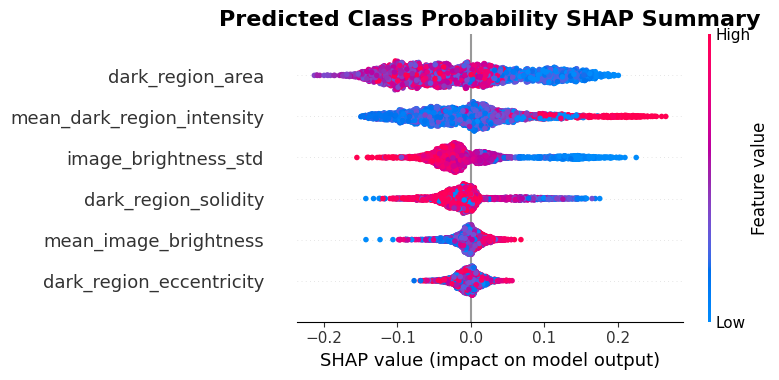

In [54]:
# ============================================================
# Prediction SHAP Summary Plot
# ============================================================

shap.summary_plot(

    prediction_shap_values,

    explanation_data,

    feature_names=CONCEPT_NAMES,

    show=False

)

plt.title(

    "Predicted Class Probability SHAP Summary",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "prediction_shap_summary",

    PREDICTION_SHAP_FIGURE_DIR

)

plt.show()

/tmp/ipykernel_883/179970899.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


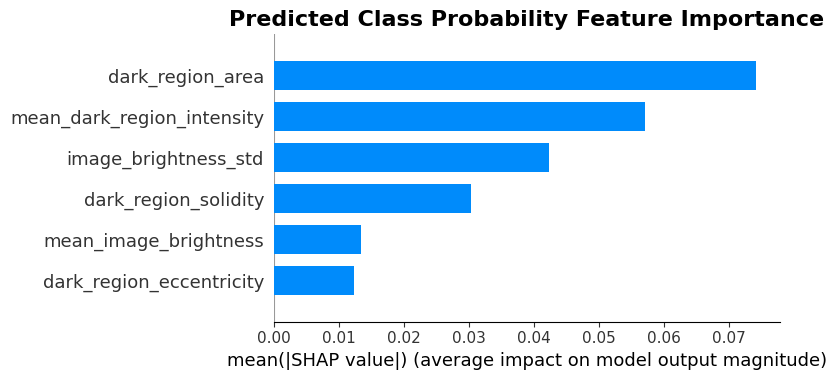

In [55]:
# ============================================================
# Prediction SHAP Feature Importance
# ============================================================

shap.summary_plot(

    prediction_shap_values,

    explanation_data,

    feature_names=CONCEPT_NAMES,

    plot_type="bar",

    show=False

)

plt.title(

    "Predicted Class Probability Feature Importance",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "prediction_shap_importance",

    PREDICTION_SHAP_FIGURE_DIR

)

plt.show()

In [56]:
# ============================================================
# Predictive Entropy KernelSHAP Explainer
# ============================================================

entropy_explainer = shap.KernelExplainer(

    predictive_entropy_function,

    background_data

)

print("=" * 70)
print("Predictive Entropy KernelSHAP Explainer Created")
print("=" * 70)

Predictive Entropy KernelSHAP Explainer Created


In [57]:
# ============================================================
# Compute Predictive Entropy SHAP Values
# ============================================================

entropy_shap_values = entropy_explainer.shap_values(

    explanation_data

)

print("=" * 70)
print("Predictive Entropy SHAP Computation Complete")
print("=" * 70)

print()

print(

    "Predictive Entropy SHAP Shape:",

    np.array(

        entropy_shap_values

    ).shape

)

  0%|          | 0/3421 [00:00<?, ?it/s]

Predictive Entropy SHAP Computation Complete

Predictive Entropy SHAP Shape: (3421, 6)


/tmp/ipykernel_883/1792655931.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


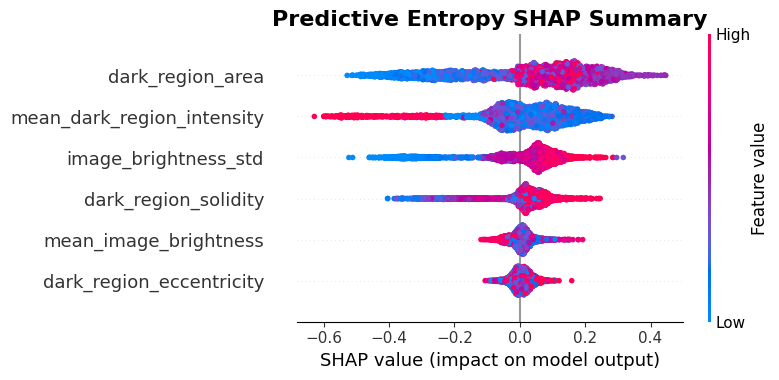

In [58]:
# ============================================================
# Predictive Entropy SHAP Summary Plot
# ============================================================

shap.summary_plot(

    entropy_shap_values,

    explanation_data,

    feature_names=CONCEPT_NAMES,

    show=False

)

plt.title(

    "Predictive Entropy SHAP Summary",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "predictive_entropy_shap_summary",

    UNCERTAINTY_SHAP_FIGURE_DIR

)

plt.show()

/tmp/ipykernel_883/731374942.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


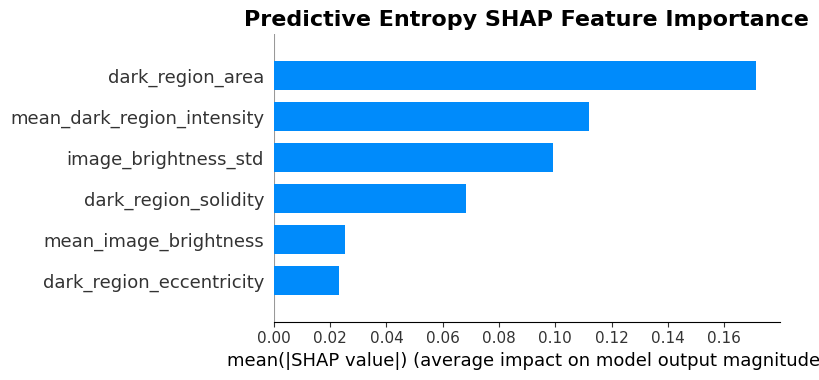

In [59]:
# ============================================================
# Predictive Entropy SHAP Feature Importance
# ============================================================

shap.summary_plot(

    entropy_shap_values,

    explanation_data,

    feature_names=CONCEPT_NAMES,

    plot_type="bar",

    show=False

)

plt.title(

    "Predictive Entropy SHAP Feature Importance",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

save_figure(

    "predictive_entropy_shap_importance",

    UNCERTAINTY_SHAP_FIGURE_DIR

)

plt.show()

In [60]:
# ============================================================
# Prediction vs Predictive Entropy SHAP Comparison
# ============================================================

prediction_importance = np.mean(

    np.abs(

        prediction_shap_values

    ),

    axis=0

)

entropy_importance = np.mean(

    np.abs(

        entropy_shap_values

    ),

    axis=0

)

comparison_df = pd.DataFrame({

    "Clinical Concept": CONCEPT_NAMES,

    "Prediction SHAP": prediction_importance,

    "Predictive Entropy SHAP": entropy_importance

})

comparison_df["Entropy / Prediction Ratio"] = (

    comparison_df["Predictive Entropy SHAP"]

    /

    comparison_df["Prediction SHAP"]

)

comparison_df = comparison_df.sort_values(

    by="Prediction SHAP",

    ascending=False

).reset_index(

    drop=True

)

print("=" * 70)
print("Prediction vs Predictive Entropy SHAP")
print("=" * 70)

display(

    comparison_df

)

save_csv(

    comparison_df,

    "prediction_vs_predictive_entropy_shap",

    UNCERTAINTY_SHAP_CSV_DIR

)

Prediction vs Predictive Entropy SHAP


,Clinical Concept,Prediction SHAP,Predictive Entropy SHAP,Entropy / Prediction Ratio
0,dark_region_area,0.074106,0.171305,2.311619
1,mean_dark_region_intensity,0.057045,0.111925,1.962054
2,image_brightness_std,0.042237,0.099226,2.349273
3,dark_region_solidity,0.030277,0.068302,2.255922
4,mean_image_brightness,0.013369,0.025242,1.888002
5,dark_region_eccentricity,0.012393,0.023013,1.856863


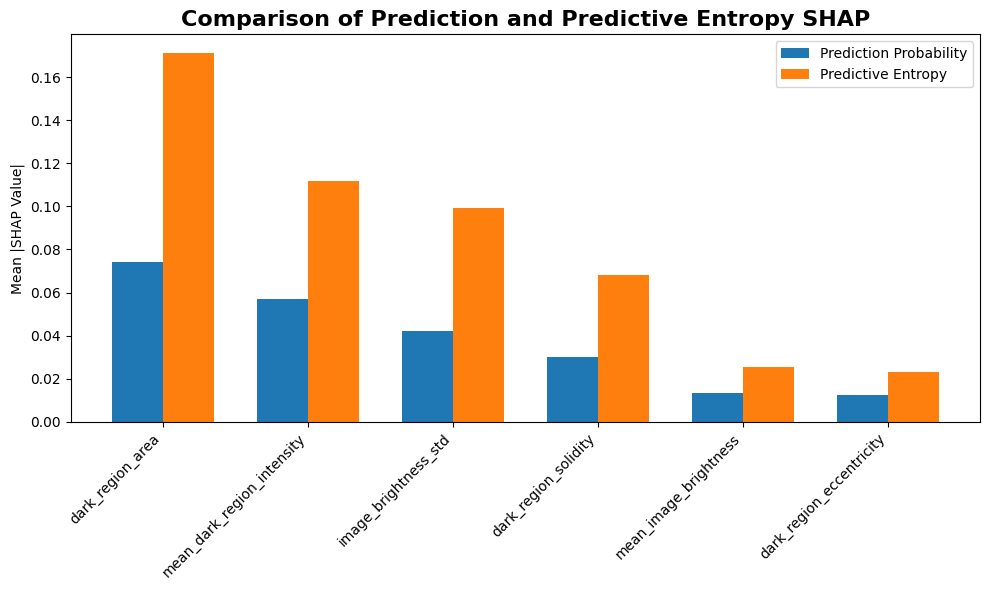

In [61]:
# ============================================================
# Prediction vs Predictive Entropy SHAP Comparison
# ============================================================

x = np.arange(

    len(CONCEPT_NAMES)

)

bar_width = 0.35

plt.figure(

    figsize=(10,6)

)

plt.bar(

    x - bar_width/2,

    comparison_df["Prediction SHAP"],

    width=bar_width,

    label="Prediction Probability"

)

plt.bar(

    x + bar_width/2,

    comparison_df["Predictive Entropy SHAP"],

    width=bar_width,

    label="Predictive Entropy"

)

plt.xticks(

    x,

    comparison_df["Clinical Concept"],

    rotation=45,

    ha="right"

)

plt.ylabel(

    "Mean |SHAP Value|"

)

plt.title(

    "Comparison of Prediction and Predictive Entropy SHAP",

    fontsize=16,

    fontweight="bold"

)

plt.legend()

plt.tight_layout()

save_figure(

    "prediction_vs_predictive_entropy_shap",

    UNCERTAINTY_SHAP_FIGURE_DIR

)

plt.show()

In [62]:
# ============================================================
# Display Case Summary
# ============================================================

def display_case_summary(index):

    print("=" * 70)
    print(f"Case Study : Sample {index}")
    print("=" * 70)

    true_class = CLASS_NAMES[

        raw_test_labels[index]

    ]

    predicted_class = CLASS_NAMES[

        predicted_classes[index]

    ]

    prediction_probability = mean_prediction[

        index,

        predicted_classes[index]

    ]

    entropy = predictive_entropy[index]

    print(f"True Class            : {true_class}")
    print(f"Predicted Class       : {predicted_class}")
    print(f"Prediction Correct    : {true_class == predicted_class}")
    print(f"Prediction Probability: {prediction_probability:.4f}")
    print(f"Predictive Entropy    : {entropy:.4f}")

In [63]:
# ============================================================
# Display Case Image
# ============================================================

def display_case_image(index, case_name):

    plt.figure(

        figsize=(4, 4)

    )

    plt.imshow(

        raw_test_images[index]

    )

    plt.title(

        f"True : {CLASS_NAMES[raw_test_labels[index]]}\n"
        f"Pred : {CLASS_NAMES[predicted_classes[index]]}"

    )

    plt.axis(

        "off"

    )

    plt.tight_layout()

    save_figure(

        f"{case_name.lower().replace(' ', '_')}_image",

        UNCERTAINTY_SHAP_FIGURE_DIR

    )

    plt.show()

In [64]:
# ============================================================
# Display SHAP Waterfalls
# ============================================================

def display_case_shap(index, case_name):

    print("=" * 70)
    print("Prediction SHAP")
    print("=" * 70)

    prediction_explanation = shap.Explanation(

        values=prediction_shap_values[index],

        base_values=prediction_explainer.expected_value,

        data=X_test[index],

        feature_names=CONCEPT_NAMES

    )

    shap.plots.waterfall(

        prediction_explanation,

        max_display=6,

        show=True

    )

    save_figure(

        f"{case_name.lower().replace(' ', '_')}_prediction_shap",

        UNCERTAINTY_SHAP_FIGURE_DIR

    )

    print("=" * 70)
    print("Predictive Entropy SHAP")
    print("=" * 70)

    entropy_explanation = shap.Explanation(

        values=entropy_shap_values[index],

        base_values=entropy_explainer.expected_value,

        data=X_test[index],

        feature_names=CONCEPT_NAMES

    )

    shap.plots.waterfall(

        entropy_explanation,

        max_display=6,

        show=True

    )

    save_figure(

        f"{case_name.lower().replace(' ', '_')}_entropy_shap",

        UNCERTAINTY_SHAP_FIGURE_DIR

    )

Most Certain Representative from Each Class
Basophil            Index: 3045 Entropy: 0.7946
Eosinophil          Index: 1174 Entropy: 0.6721
Erythroblast        Index: 2857 Entropy: 0.1033
Immature GranulocyteIndex: 2434 Entropy: 0.3601
Lymphocyte          Index: 2786 Entropy: 0.4077
Monocyte            Index: 1066 Entropy: 0.8297
Neutrophil          Index: 2716 Entropy: 0.0988
Platelet            Index: 3067 Entropy: 0.0042

Selected Representative:
Platelet (Index 3067) Entropy = 0.0042
Case Study : Sample 3067
True Class            : Platelet
Predicted Class       : Platelet
Prediction Correct    : True
Prediction Probability: 0.9995
Predictive Entropy    : 0.0042


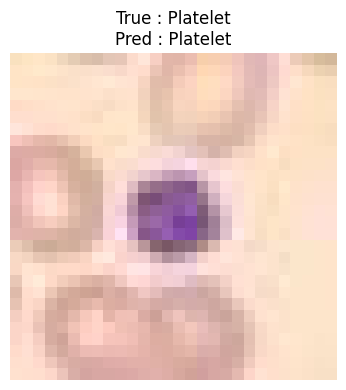

Prediction SHAP


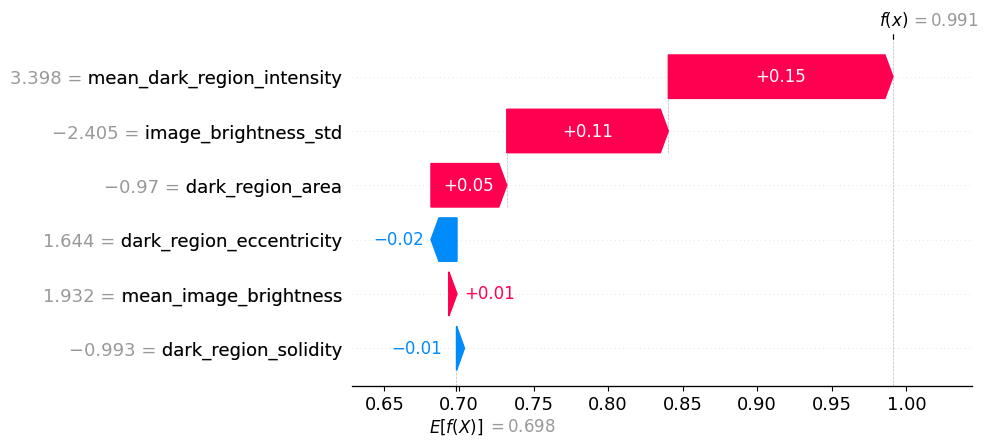

Predictive Entropy SHAP


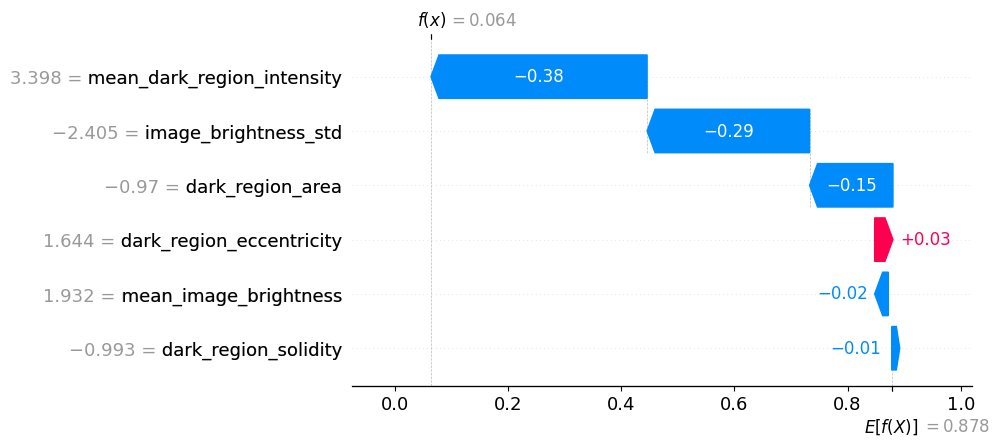

<Figure size 640x480 with 0 Axes>

In [65]:
# ============================================================
# Case Study 1 : Representative High-Confidence Sample
# ============================================================

print("=" * 70)
print("Most Certain Representative from Each Class")
print("=" * 70)

for idx in certain_indices:

    print(
        f"{CLASS_NAMES[raw_test_labels[idx]]:<20}"
        f"Index: {idx:<5}"
        f"Entropy: {predictive_entropy[idx]:.4f}"
    )

# ------------------------------------------------------------
# Select the representative with the lowest predictive entropy
# ------------------------------------------------------------

most_certain_index = certain_indices[
    np.argmin(
        predictive_entropy[certain_indices]
    )
]

print("\nSelected Representative:")
print(
    f"{CLASS_NAMES[raw_test_labels[most_certain_index]]} "
    f"(Index {most_certain_index}) "
    f"Entropy = {predictive_entropy[most_certain_index]:.4f}"
)

display_case_summary(

    most_certain_index

)

display_case_image(

    most_certain_index,

    "Representative High-Confidence"

)

display_case_shap(

    most_certain_index,

    "Representative High-Confidence"

)

Most Uncertain Representative from Each Class
Basophil            Index: 3152 Entropy: 1.6936
Eosinophil          Index: 308  Entropy: 1.6720
Erythroblast        Index: 320  Entropy: 1.7088
Immature GranulocyteIndex: 1476 Entropy: 1.7021
Lymphocyte          Index: 802  Entropy: 1.6830
Monocyte            Index: 372  Entropy: 1.7247
Neutrophil          Index: 1499 Entropy: 1.6108
Platelet            Index: 3205 Entropy: 0.8647

Selected Representative:
Monocyte (Index 372) Entropy = 1.7247
Case Study : Sample 372
True Class            : Monocyte
Predicted Class       : Immature Granulocyte
Prediction Correct    : False
Prediction Probability: 0.3034
Predictive Entropy    : 1.7247


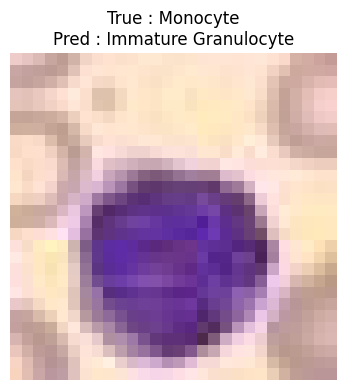

Prediction SHAP


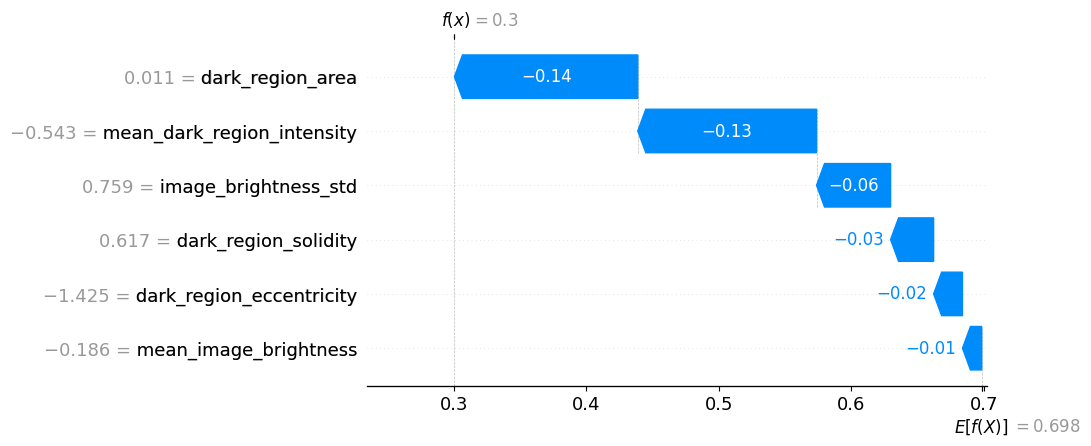

Predictive Entropy SHAP


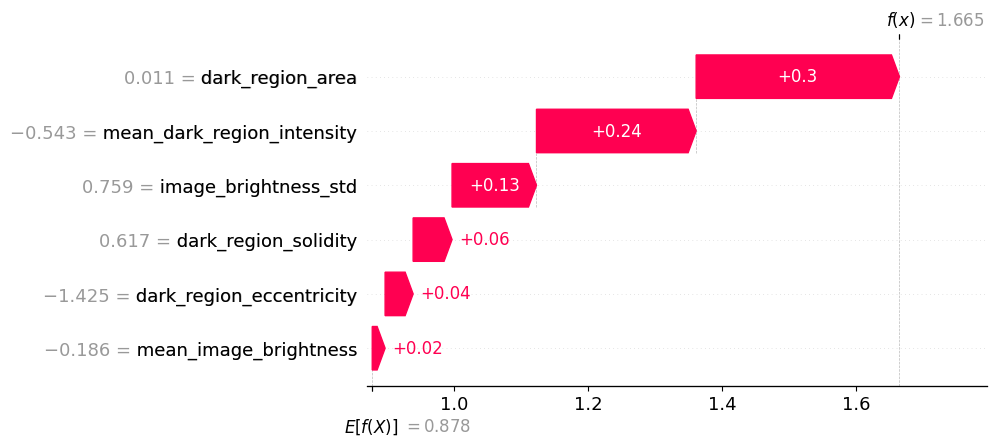

<Figure size 640x480 with 0 Axes>

In [66]:
# ============================================================
# Case Study 2 : Representative High-Uncertainty Sample
# ============================================================

print("=" * 70)
print("Most Uncertain Representative from Each Class")
print("=" * 70)

for idx in uncertain_indices:

    print(
        f"{CLASS_NAMES[raw_test_labels[idx]]:<20}"
        f"Index: {idx:<5}"
        f"Entropy: {predictive_entropy[idx]:.4f}"
    )

# ------------------------------------------------------------
# Select the representative with the highest predictive entropy
# ------------------------------------------------------------

most_uncertain_index = uncertain_indices[
    np.argmax(
        predictive_entropy[uncertain_indices]
    )
]

print("\nSelected Representative:")
print(
    f"{CLASS_NAMES[raw_test_labels[most_uncertain_index]]} "
    f"(Index {most_uncertain_index}) "
    f"Entropy = {predictive_entropy[most_uncertain_index]:.4f}"
)

display_case_summary(

    most_uncertain_index

)

display_case_image(

    most_uncertain_index,

    "Representative High-Uncertainty"

)

display_case_shap(

    most_uncertain_index,

    "Representative High-Uncertainty"

)

Representative Random Sample
Selected Index : 3174
Class          : Neutrophil
Entropy        : 0.5566
Case Study : Sample 3174
True Class            : Neutrophil
Predicted Class       : Neutrophil
Prediction Correct    : True
Prediction Probability: 0.8205
Predictive Entropy    : 0.5566


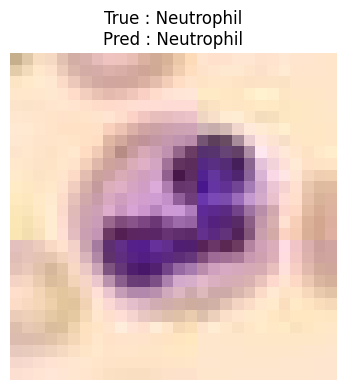

Prediction SHAP


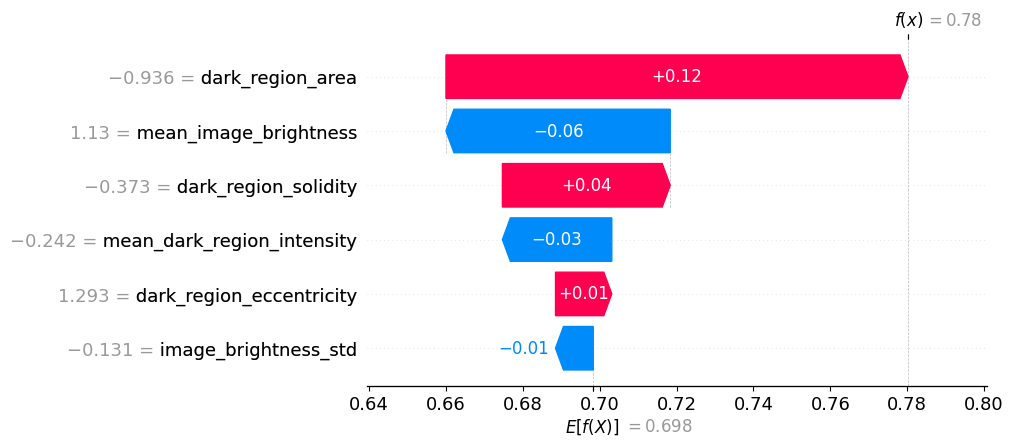

Predictive Entropy SHAP


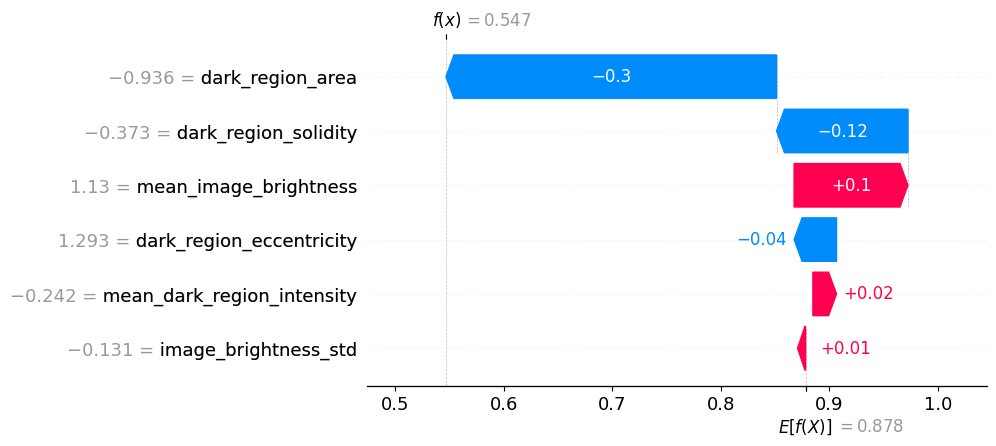

<Figure size 640x480 with 0 Axes>

In [67]:
# ============================================================
# Case Study 3 : Representative Random Sample
# ============================================================

np.random.seed(

    SHAP_RANDOM_SEED

)

random_index = np.random.randint(

    0,

    len(X_test)

)

print("=" * 70)
print("Representative Random Sample")
print("=" * 70)

print(
    f"Selected Index : {random_index}\n"
    f"Class          : {CLASS_NAMES[raw_test_labels[random_index]]}\n"
    f"Entropy        : {predictive_entropy[random_index]:.4f}"
)

display_case_summary(

    random_index

)

display_case_image(

    random_index,

    "Representative Random"

)

display_case_shap(

    random_index,

    "Representative Random"

)

In [68]:
import shutil
from google.colab import files

shutil.make_archive("/content/ConceptScope_final", "zip", "/content/ConceptScope")
files.download("/content/ConceptScope_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>